# Основные формы записи уравнений динамики ИСЗ

## Введение

Математическое моделирование и аналитическое исследование орбитального движения искусственных спутников Земли (ИСЗ) требуют выбора системы дифференциальных уравнений, адекватной физической природе действующих пертурбационных факторов [Брумберг, 1980]. Переход от декартовых координат к оскулирующим элементам позволяет разделить движение космического аппарата на быструю орбитальную составляющую (витковое вращение) и медленные эволюции (вековой и долгопериодический дрейф параметров под действием малых возмущающих сил) [Брумберг, 1980; Meyer, Hall, 1992].

В настоящем конспекте представлены уравнения динамики ИСЗ в различных формах записи, применяемые в аналитических и численных методах. Изложение направлено на установление связи между математическим аппаратом групп Ли и прикладными алгоритмами теории возмущений высших порядков, а также на разграничение областей применимости канонических (симплектических) и неканонических дифференциальных систем [Whittaker, 1937; Kamel, 1970; Deprit, 1969].


## 1. Системы координат в задачах динамики ИСЗ

Для построения математических моделей движения искусственных спутников Земли и корректного аналитического учета возмущающих сил необходимо зафиксировать набор опорных систем координат (СК). В зависимости от специфики решаемой задачи — интегрирования дифференциальных уравнений движения, вычисления компонент геопотенциала или баллистического прогнозирования по полуаналитическим теориям - используются инерциальные, вращающиеся или сопутствующие орбитальные базисы [Брумберг, 1980; Эльясберг, 1965].

### 1.1. Геоцентрические квазиинерциальные системы координат

Инерциальные системы координат служат основой для записи уравнений динамики (Ньютона, Лагранжа, Гамильтона), поскольку в них выполняются классические законы механики в отсутствие переносных сил инерции [Арнольд, 1989]. На практике реализуются квазиинерциальные системы с началом в центре масс Земли, оси которых жестко зафиксированы на определенную астрономическую эпоху [Aksenov, 1977].

*   **GCRS (Geocentric Celestial Reference System) / Небесная международная система:** Современный эталонный стандарт Международного астрономического союза (IAU) и Международной службы вращения Земли (IERS) [IERS Technical Note No. 36, 2010]. Её начало совпадает с барицентром Солнечной системы (для BCRS) или геоцентром (для GCRS), а ориентация осей кинематически зафиксирована в пространстве относительно удаленных внегалактических радиоисточников (квазаров) и не зависит от изменения параметров вращения Земли. Направление осей GCRS с высокой точностью совпадает с осями исторической системы J2000.0.
*   **ECI (Earth-Centered Inertial) / Эпоха J2000.0:** Классическая квазиинерциальная геоцентрическая система координат, традиционно используемая в аналитических теориях движения ИСЗ [Brouwer, 1959; Ипатов и др., 2002]. Начало координат совмещено с центром масс Земли. Базовой плоскостью $XY$ является плоскость среднего земного экватора, зафиксированная на эпоху фундаментального каталога J2000.0 (полдень 1 января 2000 года). Ось $X$ направлена в точку весеннего равноденствия указанной эпохи, ось $Z$ направлена вдоль средней оси вращения Земли, а ось $Y$ дополняет систему до правой.
*   **TEME (True Equator Mean Equinox / Истинный экватор, среднее равноденствие):** Специализированная геоцентрическая квазиинерциальная система координат, занимающая промежуточное положение в алгоритмах редукции [Escobal, 1976]. Особенность её определения заключается в том, что ось $Z$ направлена вдоль истинной (мгновенной) оси вращения Земли с учетом нутации, однако ось $X$ направлена в точку среднего весеннего равноденствия (смещение из-за уравнения равноденствий игнорируется). 

> **Примечание:** Система TEME является единственным штатным базисом для реализации аналитического алгоритма SGP4. Использование GCRS или J2000.0 напрямую в формулах SGP4 без предварительного пересчета приводит к деградации точности баллистических эфемерид ИСЗ [Hoots, Roehrich, 1980; Vallado et al., 2006].

---

### 1.2. Земные вращающиеся системы координат

Земные (гринвичские) системы координат связаны с телом планеты и вращаются вместе с ней вокруг полярной оси с угловой скоростью $\omega_E$. Они необходимы для вычисления высоты полета ИСЗ, определения географических координат подспутниковых точек, а также для аналитического представления потенциала несферичности Земли, который консервативно зафиксирован в теле планеты [Эльясберг, 1965; Каменский, 2018].

*   **ITRF (International Terrestrial Reference Frame) / Земная международная система:** Современный международный стандарт реализации геоцентрической земной системы координат, обновляемый IERS [IERS Technical Note No. 40, 2025]. Начало координат находится в центре масс Земли (включая гидросферу и атмосферу). Ориентация осей задается международными соглашениями: ось $Z$ направлена к условному земному полюсу (IERS Reference Pole), ось $X$ лежит в плоскости нулевого меридиана (IERS Reference Meridian), а ось $Y$ образует правую систему. ITRF учитывает вековой дрейф полюсов, тектоническое движение материковых плит и приливные деформации земной коры посредством непрерывного мониторинга методами космической геодезии (VLBI, SLR, GNSS).
*   **ECEF (Earth-Centered, Earth-Fixed):** Общий класс прикладных геоцентрических систем, жестко связанных с вращающейся планетой, в котором пренебрегают мелкими эффектами движения полюсов и деформаций коры [Montenbruck, Gill, 2000]. Наиболее широко используемой в спутниковой навигации является общеземная геодезическая система WGS-84 (World Geodetic System 1984). Базовая плоскость совпадает с плоскостью экватора, ось $X$ направлена на Гринвичский меридиан, ось $Z$ совпадает со средней осью вращения Земли и направлена к Северному полюсу. Гравитационный потенциал Земли (например, модели EGM96 или EGM2008) всегда задается коэффициентами тессеральных, секторальных и зональных гармоник исключительно в осях систем класса ECEF [Мюррей, Дермотт, 2010].

---

### 1.3. Сопутствующий орбитальный репер

Для аналитического моделирования и вычисления проекций сил, зависящих от пространственного положения космического аппарата и вектора его скорости (аэродинамическое сопротивление атмосферы, давление светового излучения), вводится локальная подвижная система координат, начало которой совмещено с центром масс ИСЗ [Охоцимский, Сихарулидзе, 1990]. Ось сопутствующего орбитального репера определяется взаимной геометрией радиус-вектора $\vec{r}$ и вектора скорости $\vec{v}$ спутника:

*   **Радиальная ось ($S$):** Направлена по геоцентрическому радиус-вектору космического аппарата (от центра масс Земли к спутнику).
*   **Трансверсальная ось ($T$):** Лежит в мгновенной плоскости орбиты ИСЗ, ортогональна радиальной оси $S$ и направлена в сторону движения космического аппарата. 
    *   *Примечание:* Трансверсальная ось совпадает по направлению с вектором скорости $\vec{v}$ только на строго круговой орбите; на эллиптических траекториях между ними существует угол направления полета из-за ненулевой радиальной скорости [Lundberg et al., 2004].
*   **Бинормальная ось ($W$):** Направлена по нормали к мгновенной плоскости орбиты ИСЗ, дополняя систему до правой. Направление оси совпадает с направлением вектора орбитального момента количества движения спутника $\vec{c} = \vec{r} \times \vec{v}$.

Разложение малых неконсервативных возмущающих ускорений по осям репера $(S, T, W)$ формирует основу для неканонических уравнений Ньютона в оскулирующих элементах [Брумберг, 1980].


### 1.4. Основные наборы элементов орбиты ИСЗ

В зависимости от геометрических характеристик траектории (высота орбиты, наличие критических наклонений, близость эксцентриситета к нулю) и используемого математического аппарата (канонический или неканонический), состояние космического аппарата в фазовом пространстве представляют различными наборами оскулирующих элементов [Брумберг, 1980; Балк, 1975]. Выделяют следующие системы элементов:

#### 1.4.1. Классические геометрические элементы Кеплера
Являются стандартным неканоническим базисом, описывающим пространственную геометрию и ориентацию орбиты как конического сечения [Эльясберг, 1965].
*   **Состав вектора:** $x = (a, e, i, \omega, \Omega, M)^T$ (вместо средней аномалии $M$ может использоваться истинная аномалия $\vartheta$ или момент прохождения перигея $T_0$).
*   **Сингулярности:** Базис полностью вырождается для круговых ($e \to 0$, неопределенность положения перицентра $\omega$) и экваториальных ($i \to 0$, неопределенность долготы восходящего узла $\Omega$) орбит, порождая малые знаменатели в правых частях дифференциальных уравнений Ньютона и Лагранжа.

#### 1.4.2. Канонические элементы Делоне
Представляют собой канонический базис типа «действие-угол», переводящий гамильтонову систему ИСЗ на язык симплектической геометрии и пуассоновых алгебр [Whittaker, 1937].
*   **Состав вектора:** $x = (L, G, H_{\mathrm{del}}, l, g, h)^T$.
*   **Преимущества:** Невозмущенный гамильтониан Келетра $H_0(L) = -\mu^2 / (2L^2)$ зависит исключительно от одного главного действия $L$. Это позволяет напрямую применять операторные методы теории групп Ли (алгоритмы Хори и Депри) для усреднения и аналитического исключения быстрой фазы без разрастания промежуточных полиномов [Deprit, 1969].
*   **Сингулярности:** Полностью наследуют тригонометрические особенности элементов Кеплера при $e \to 0$ и $i \to 0$ (неопределенности углов Делоне $g$ и $h$).

#### 1.4.3. Неканонические эквипотенциальные элементы равноденствия (Equinoctial Elements)
Разработаны для устранения координатных сингулярностей круговых и экваториальных орбит в численных и полуаналитических методах без перехода к альтернативным каноническим преобразованиям Пуанкаре [Arsenault et al., 1970; Broucke, Cefola, 1972].
*   **Состав вектора:** $x = (a, h_x, k_x, p_x, q_x, \lambda_x)^T$, где:
    $$h_x = e \sin(\omega + \Omega), \quad k_x = e \cos(\omega + \Omega)$$
    $$p_x = \tan\frac{i}{2} \sin \Omega, \quad q_x = \tan\frac{i}{2} \cos \Omega, \quad \lambda_x = M + \omega + \Omega$$
*   **Преимущества:** Компоненты вектора остаются регулярными и гладкими при $e \to 0$ и $i \to 0$. Средняя долгота $\lambda_x$ равномерно нарастает во времени. Данный набор является основой для современных полуаналитических теорий движения ИСЗ, включая стандарт DSST (Draper Semi-analytical Satellite Theory) [Danielson et al., 1995].
*   **Недостатки:** Уравнения движения в этих переменных являются неканоническими и требуют вычисления сложных матричных проекций сил Гаусса. Имеют сингулярность при строго ретроградных экваториальных орбитах ($i \to \pi$).

#### 1.4.4. Модифицированные элементы равноденствия (Modified Equinoctial Elements)
Модификация элементов равноденствия, предназначенная для сквозного моделирования траекторий ИСЗ с произвольным эксцентриситетом, включая параболические и гиперболические траектории [Walker et al., 1985].
*   **Состав вектора:** $x = (p, f_x, g_x, h_x, k_x, L_x)^T$, где вместо большой полуоси $a$ вводится фокальный параметр $p = a(1 - e^2)$, а быстрой переменной служит истинная долгота спутника:
    $$L_x = \vartheta + \omega + \Omega$$

#### 1.4.5. Канонические элементы Пуанкаре первого и второго рода
Представляют собой регулярный симплектический базис, сочетающий отсутствие координатных сингулярностей элементов равноденствия с сохранением строгой структуры гамильтоновых систем Уиттекера [Poincaré, 1892].
*   **Состав вектора (2-го рода):** $x = (\Lambda, \xi, p_{\mathrm{P}}, \lambda, \eta, q_{\mathrm{P}})^T$.
*   **Преимущества:** Единственная форма регулярных канонических переменных, позволяющая строить высшие порядки аналитических спутниковых теорий возмущений методами Ли-Депри в окрестности околокруговых и околоэкваториальных режимов (включая геостационарные спутники) без нарушения симплектической структуры пространства [Брумберг, 1980].

#### 1.4.6. Средние элементы орбиты в полуаналитических теориях

В отличие от оскулирующих параметров, отражающих мгновенное состояние ИСЗ с учетом всех кратковременных флуктуаций, средние элементы орбиты строятся посредством исключения (усреднения) короткопериодических возмущений, зависящих от быстрой циклической фазы (средней аномалии или средней долготы) [Брумберг, 1980]. Математическая связь между вектором средних элементов $\bar{x}$ и вектором оскулирующих элементов $x$ задается нелинейным оператором преобразования, раскрываемым в виде рядов по малому параметру задачи $\epsilon$:
$$x = \bar{x} + \sum_{k=1}^{\infty} \epsilon^k \cdot \delta x^{(k)}(\bar{x})$$
где $\delta x^{(k)}$ - высокочастотные периодические поправки $k$-го порядка малости.

*   **Динамические особенности:** В пространстве средних элементов правые части дифференциальных уравнений движения содержат исключительно вековые и долгопериодические составляющие возмущений. Это позволяет интегрировать систему с шагом, соизмеримым с периодом обращения линии апсид или линии узлов (сотни часов), что существенно снижает вычислительные затраты. Средние элементы служат математической основой для полуаналитических теорий вековой эволюции орбит ИСЗ высших порядков (например, алгоритмов Брауэра и теории DSST).

#### 1.4.7. Двухстрочные наборы элементов TLE (Two-Line Element) и алгоритм SGP4

Двухстрочные наборы элементов TLE представляют собой специализированный стандарт кодирования средних элементов орбиты ИСЗ, поддерживаемый Командованием воздушно-космической обороны Северной Америки (NORAD) [Vallado et al., 2006]. Набор TLE содержит вектор средних параметров Кеплера на определенный момент времени (эпоху), а также феноменологические коэффициенты торможения (параметр $B^*$), учитывающие диссипативное влияние верхних слоев атмосферы.

*   **Математическая специфика и ограничения:** Параметры TLE являются результатом аппроксимации реальных траекторий ИСЗ по строго определенной аналитической теории возмущений - алгоритму SGP4 (или SGP8/SDP4) [Hoots, Roehrich, 1980]. Модель SGP4 включает в себя аналитический учет вековых и короткопериодических возмущений от гармоник геопотенциала $J_2, J_3, J_4$, а также упрощенную модель атмосферного торможения. 
*   **Особенности использования:** Средние элементы TLE неотделимы от математической структуры алгоритма SGP4. Прямой пересчет компонент TLE в декартовы координаты по формулам невозмущенной задачи Кеплера (без учета периодических поправок SGP4) или их подстановка в качестве начальных условий в альтернативные численные интеграторы ОДУ Ньютона приводит к потере точности баллистических эфемерид (с ошибкой до десятков километров на интервале суток).


## 2. Декартова форма уравнений движения (уравнения Ньютона в координатах)

Базовой формой математического описания орбитального полета космического аппарата является запись уравнений движения во временной области в декартовых координатах квазиинерциальной геоцентрической системы ($GCRS$ или $J2000.0$) [Montenbruck, Gill, 2000]. Состояние системы с тремя степенями свободы ($n = 3$) представляется вектором $x = (\vec{r}, \vec{v})^T \in \mathbb{R}^6$, где вектор положения $\vec{r} = (x, y, z)^T$ является контравариантным объектом, а вектор скоростей $\vec{v} = (\dot{x}, \dot{y}, \dot{z})^T$ задает его первую производную по времени.

Дифференциальные уравнения возмущенного движения ИСЗ первого порядка принимают вид:
$$\frac{dx}{dt} = \begin{pmatrix} \vec{v} \\ \vec{a}_{\mathrm{central}} + \vec{a}_{\mathrm{perturb}} \end{pmatrix}$$

где центральное ньютоновское ускорение $\vec{a}_{\mathrm{central}}$ обусловлено гравитационным полем сферически симметричной Земли массы $M$:
$$\vec{a}_{\mathrm{central}} = -\frac{\mu}{\|\vec{r}\|^3}\vec{r}, \quad \mu = GM$$

Вектор общего возмущающего ускорения космического аппарата $\vec{a}_{\mathrm{perturb}}$ формируется суперпозицией независимых сил различной физической природы, разделяемых на консервативные (гамильтоновы) и диссипативные (неканонические) классы [Whittaker, 1937]:
$$\vec{a}_{\mathrm{perturb}} = \vec{a}_{\mathrm{geo}} + \vec{a}_{\mathrm{3rd}} + \vec{a}_{\mathrm{tides}} + \vec{a}_{\mathrm{atm}} + \vec{a}_{\mathrm{srp}}$$

---

### 2.1. Несферичность гравитационного поля планеты ($\vec{a}_{\mathrm{geo}}$)

*   **Математическая модель:** Данное возмущение является консервативным и доминирующим для низких и средних орбит ИСЗ. Оно порождается неоднородным распределением масс внутри Земли и её полярным сжатием. Возмущающие силы выражаются через градиент потенциала возмущения (в альтернативной нотации - возмущающей функции $\mathcal{R}$), задаваемого разложением по сферическим гармоникам в осях земной вращающейся системы координат ($ECEF$) [Эльясберг, 1965; Мюррей, Дермотт, 2010]:
    $$R_{\mathrm{geo}}(r, \phi, \lambda) = \frac{\mu}{r}\sum_{n=2}^{\infty}\sum_{m=0}^{n}\left( \frac{R_E}{r} \right)^n P_{nm}(\sin \phi) \left[ C_{nm} \cos(m\lambda) + S_{nm} \sin(m\lambda) \right]$$
    где $R_E$ - экваториальный радиус планеты, $P_{nm}$ — присоединенные функции Лежандра, $C_{nm}, S_{nm}$ - безразмерные тессеральные (при $n \neq m$) и секторальные (при $n = m$) коэффициенты. Зональные коэффициенты традиционно обозначаются как $J_n = -C_{n0}$. В баллистических расчетах высокой точности используются стандартные геопотенциальные модели $EGM96$ или $EGM2008$, усекаемые до заданного порядка в зависимости от высоты орбиты спутника [Montenbruck, Gill, 2000].
*   **Динамические эффекты:**
    1.  *Вековая прецессия под действием $J_2$:* Главная зональная гармоника $J_2$, описывающая полярное сжатие Земли, вызывает монотонное вращение плоскости орбиты - вековой дрейф долготы восходящего узла $\dot{\Omega}$ и аргумента перицентра $\dot{\omega}$. Этот эффект имеет порядок $\mathcal{O}(10^{-3})$ и целенаправленно используется для проектирования солнечно-синхронных и «замороженных» орбит.
    2.  *Долгопериодические колебания от нечетных гармоник:* Коэффициенты $J_3, J_5$ вызывают широкоамплитудные гармонические колебания эксцентриситета $e$ и наклонения $i$ с периодом обращения линии апсид.
    3.  *Тессеральные суточные резонансы:* Секторальные и тессеральные гармоники при соизмеримости частоты обращения ИСЗ и осевого вращения Земли приводят к долгопериодическому маятниковому захвату большой полуоси $a$, что критично для удержания геостационарных космических аппаратов.

---

### 2.2. Гравитационное притяжение внешних тел ($\vec{a}_{\mathrm{3rd}}$)

*   **Математическая модель:** Описывает возмущающее влияние массивных третьих тел - Луны и Солнца. Это возмущение является консервативным и вычисляется в рамках ограниченной задачи трех (или более) тел. Возмущающее ускорение от внешнего тела с гравитационным параметром $\mu_{\mathrm{body}}$ и радиус-вектором $\vec{r}_{\mathrm{body}}$ имеет приливной вид [Арнольд и др., 1985; Meyer, Hall, 1992]:
    $$\vec{a}_{\mathrm{3rd}} = \mu_{\mathrm{body}} \left( \frac{\vec{r}_{\mathrm{body}} - \vec{r}}{\|\vec{r}_{\mathrm{body}} - \vec{r}\|^3} - \frac{\vec{r}_{\mathrm{body}}}{\|\vec{r}_{\mathrm{body}}\|^3} \right)$$
    Для вычисления координат Луны и Солнца во времени используются высокоточные численные теории эфемерид Лаборатории реактивного движения ($JPL$), такие как стандарты $DE405$ или $DE440$ [IERS Technical Note No. 36, 2011].
*   **Динамические эффекты:**
    1.  *Вековая прецессия элементов высоких орбит:* Влияние третьих тел растет пропорционально удалению от Земли и становится доминирующим гравитационным возмущением для геостационарных орбит ($ГСО$) и высокоэллиптических орбит ($ВЕО$). Оно порождает вековой увод наклонения орбиты $i$.
    2.  *Вековой резонанс Лидова-Козаи:* В конфигурациях с большими взаимными наклонениями дважды усредненный потенциал третьего тела вызывает крупномасштабные периодические колебания эксцентриситета и наклонения при сохранении проекции орбитального момента $C_{\mathrm{LK}} = \sqrt{1 - e^2} \cos i = \mathrm{const}$, что может привести к падению перигея спутника на поверхность планеты.

---

### 2.3. Аэродинамическое сопротивление верхней атмосферы ($\vec{a}_{\mathrm{atm}}$)

*   **Математическая модель:** Представляет собой диссипативную, неканоническую силу. Возникает из-за механического соударения космического аппарата с молекулами газа верхней термосферы и экзосферы. Ускорение направлено строго противоположно вектору скорости спутника относительно вращающейся воздушной среды $\vec{v}_{\mathrm{rel}}$ [Эльясберг, 1965]:
    $$\vec{a}_{\mathrm{atm}} = -\frac{1}{2}\rho \frac{C_D A}{m} \|\vec{v}_{\mathrm{rel}}\|\vec{v}_{\mathrm{rel}}$$
    где $\rho$ - локальная плотность атмосферы, $C_D$ - безразмерный коэффициент лобового сопротивления, $A$ - площадь миделевого сечения космического аппарата, $m$ — масса спутника. Величина плотности испытывает экспоненциальное падение с высотой и сильные временные флуктуации под действием солнечной активности. В баллистических комплексах моделирования плотности применяются полуэмпирические стандарты $NRLMSISE-00$ или динамические модели семейства $JB2008$ [Montenbruck, Gill, 2000].
*   **Динамические эффекты:**
    1.  *Вековое снижение большой полуоси:* Диссипация механической энергии вызывает монотонное падение большой полуоси и сокращение периода обращения ИСЗ ($\dot{a} < 0$).
    2.  *Скругление орбиты:* Атмосферное торможение действует преимущественно в окрестности перигея, где плотность максимальна. Это приводит к избирательному снижению высоты апогея, вызывая падение эксцентриситета орбиты ($e \to 0$) на эволюционном масштабе времени.

---

### 2.4. Давление прямого солнечного излучения ($\vec{a}_{\mathrm{srp}}$)

*   **Математическая модель:** Относится к классу нестационарных возмущений. Порождается передачей импульса фотонов солнечного света элементам конструкции ИСЗ. В простейшей модели сферического аппарата с поглощающей поверхностью ускорение направлено вдоль вектора «Солнце - космический аппарат» [Мюррей, Дермотт, 2010]:
    $$\vec{a}_{\mathrm{srp}} = \nu P_{\mathrm{srp}} \frac{A}{m} \frac{\vec{r} - \vec{r}_{\odot}}{\|\vec{r} - \vec{r}_{\odot}\|^3} R_{\odot}^2$$
    где $P_{\mathrm{srp}}$ - давление солнечного излучения на расстоянии одной астрономической единицы, $\vec{r}_{\odot}$ — радиус-вектор Солнца, а $\nu \in [0, 1]$ - разрывная скалярная функция тени (цилиндрической или конической модели тени Земли). Учет сложной геометрии переизлучения и отражения от солнечных батарей требует векторных моделей класса *Macro-Model* [Lundberg et al., 2004].
*   **Динамические эффекты:**
    1.  *Долгопериодические изменения эксцентриситета:* Световое давление вызывает гармонические колебания эксцентриситета $e$ с периодом, равным одному году. Для спутников с большим отношением площади к массе ($A/m$) амплитуда колебаний может критически снизить высоту перигея.
    2.  *Неавтономность и необходимость расширения пространства:* Явная зависимость положения Солнца от физического времени делает систему неавтономной, что требует перехода к переменным Уиттекера в расширенном фазовом пространстве размерности 8 для сохранения канонической лиевой структуры асимптотических методов [Deprit, 1969].

---

### 2.5. Приливные деформации Земли ($\vec{a}_{\mathrm{tides}}$)

*   **Математическая модель:** Консервативное возмущение, вызванное тем, что гравитационные поля Луны и Солнца деформируют упругое тело Земли, смещая массы океанов и коры. Это смещение масс порождает добавочный нестационарный гравитационный потенциал, который накладывается на базовый геопотенциал. Математически учитывается через введение динамических поправок в коэффициенты геопотенциала $C_{nm}, S_{nm}$ с помощью чисел Лава в соответствии со стандартами IERS [IERS Conventions, 2010].
*   **Динамические эффекты:** Индуцирует мелкие долгопериодические колебания всех кеплеровых элементов орбиты ИСЗ, учет которых необходим при субсантиметровом прогнозировании траекторий геодезических космических аппаратов (например, *LAGEOS*).


### 2.6. Вычислительный эксперимент: Интегрирование декартовой системы и анализ эволюции элементов орбиты

Для верификации математических моделей и визуализации динамических эффектов, описанных в подразделах 2.1–2.5, реализуем численный эксперимент. В качестве силовой модели выберем центральное гравитационное поле Земли и возмущающее ускорение от главной зональной гармоники $J_2$:
$$\vec{a}_{J_2} = -\frac{3}{2}\frac{J_2\mu R_E^2}{\|\vec{r}\|^5} \left[ \left(1 - 5\frac{z^2}{\|\vec{r}\|^2}\right)\vec{r} + 2z\vec{k} \right]$$

Эксперимент выполняется по следующему алгоритму:
1. Задаются начальные условия в геометрических элементах Кеплера, удаленных от областей кругового и экваториального вырождения ($e_0 = 0.1$, $i_0 = 45^\circ$).
2. Осуществляется аналитический переход от элементов Кеплера к начальному декартову вектору состояния в инерциальной системе координат ($ECI$).
3. Производится численное интегрирование декартовых уравнений Ньютона на интервале времени, равном одному полному орбитальному витку, методом $DOP853$.
4. Полученный непрерывный декартов трек проецируется обратно в пространство геометрических элементов для анализа короткопериодических колебаний.

#### 2.6.1. Численные значения векторов состояния на начальную эпоху $t_0 = 0$

Зафиксируем точные числовые значения компонент обоих векторов состояния. Перевод угловых величин из градусов в радианы выполнен в соответствии с ISO-стандартами.

1. Заданный начальный вектор в элементах Кеплера ($x_{\mathrm{Kep,0}}$):
$$x_{\mathrm{Kep,0}} = \begin{pmatrix} a_0 \\ e_0 \\ i_0 \\ \omega_0 \\ \Omega_0 \\ M_0 \end{pmatrix} = \begin{pmatrix} 7200.0 \text{ км} \\ 0.100000 \\ 45.0000^\circ \\ 30.0000^\circ \\ 60.0000^\circ \\ 0.0000^\circ \end{pmatrix} \equiv \begin{pmatrix} 7200.000000 \text{ км} \\ 0.100000 \\ 0.785398 \text{ рад} \\ 0.523599 \text{ рад} \\ 1.047198 \text{ рад} \\ 0.000000 \text{ рад} \end{pmatrix}$$

2. Рассчитанный тождественный вектор в декартовых координатах ECI ($x_{\mathrm{ECI,0}}$): 
В результате выполнения нелинейного координатного отображения на эпоху $t_0 = 0$ (чему при выбранных условиях соответствует значение истинной аномалии $\vartheta_0 = 0$ в перигее) получены следующие точные значения проекций радиус-вектора и вектора скоростей ИСЗ:
$$x_{\mathrm{ECI,0}} = \begin{pmatrix} \vec{r}_0 \\ \vec{v}_0 \end{pmatrix} = \begin{pmatrix} x_0 \\ y_0 \\ z_0 \\ \dot{x}_0 \\ \dot{y}_0 \\ \dot{z}_0 \end{pmatrix} = \begin{pmatrix} 1334.805560 \text{ км} \\ 5797.747384 \text{ км} \\ 2757.261903 \text{ км} \\ -7.135248 \text{ км/с} \\ 0.814343 \text{ км/с} \\ 2.457199 \text{ км/с} \end{pmatrix}$$

Зафиксированный декартов вектор выступает в качестве вектора начальных данных задачи Коши для эталонного дифференциального ядра Ньютона.


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =========================================================================
# 1. ГЛОБАЛЬНЫЕ БАЛЛИСТИЧЕСКИЕ КОНСТАНТЫ (МОДЕЛЬ WGS-84)
# =========================================================================
mu = 398600.4418     # Гравитационный параметр Земли, км^3/с^2
R_E = 6378.137       # Экваториальный радиус Земли, км
J_2 = 1.082626e-3    # Безразмерный коэффициент сжатия

# =========================================================================
# 2. УНИФИЦИРОВАННЫЕ ОПЕРАТОРЫ КООРДИНАТНЫХ ОТОБРАЖЕНИЙ
# =========================================================================
def kepler_to_rv(a, e, i, omega, Omega, M):
    """ Преобразование оскулирующих элементов Кеплера в декартовы координаты (ECI) """
    E = M
    for _ in range(10):
        E = E - (E - e * np.sin(E) - M) / (1.0 - e * np.cos(E))
        
    nu = 2.0 * np.arctan2(np.sqrt(1.0 + e) * np.sin(E / 2.0), np.sqrt(max(0.0, 1.0 - e)) * np.cos(E / 2.0))
    p = a * (1.0 - e**2)
    r = p / (1.0 + e * np.cos(nu))
    
    r_orb = np.array([r * np.cos(nu), r * np.sin(nu), 0.0])
    v_orb = np.array([-np.sqrt(mu / p) * np.sin(nu), np.sqrt(mu / p) * (e + np.cos(nu)), 0.0])
    
    cO, sO = np.cos(Omega), np.sin(Omega)
    co, so = np.cos(omega), np.sin(omega)
    ci, si = np.cos(i), np.sin(i)
    
    R_mat = np.array([
        [cO*co - sO*so*ci, -cO*so - sO*co*ci, sO*si],
        [sO*co + cO*so*ci, -sO*so + cO*co*ci, -cO*si],
        [so*si,             co*si,             ci]
    ])
    return np.dot(R_mat, r_orb), np.dot(R_mat, v_orb), nu, r

def rv_to_kepler(r_vec, v_vec):
    """ Преобразование декартовых координат (ECI) в оскулирующие элементы Кеплера """
    r = np.linalg.norm(r_vec)
    v = np.linalg.norm(v_vec)
    h_vec = np.cross(r_vec, v_vec)
    h = np.linalg.norm(h_vec)
    
    i = np.arccos(np.clip(h_vec[2] / h, -1.0, 1.0))
    n_vec = np.cross(np.array([0.0, 0.0, 1.0]), h_vec)
    n = np.linalg.norm(n_vec)
    
    # Математически строгое определение долготы восходящего узла по ортам экватора
    Omega = np.arctan2(n_vec[1], n_vec[0]) if n > 0 else 0.0
    
    e_vec = ((v**2 - mu / r) * r_vec - np.dot(r_vec, v_vec) * v_vec) / mu
    e = np.linalg.norm(e_vec)
    
    e_safe = max(e, 1e-12)
    n_safe = max(n, 1e-12)
    
    omega = np.arctan2(np.dot(np.cross(n_vec, e_vec), h_vec) / (h * n_safe), np.dot(n_vec, e_vec) / n_safe) if n > 0 else 0.0
    nu = np.arctan2(np.dot(np.cross(e_vec, r_vec), h_vec) / (h * e_safe), np.dot(e_vec, r_vec) / e_safe)
    
    E_anomaly = 2.0 * np.arctan2(np.sqrt(max(0.0, 1.0 - e)) * np.sin(nu / 2.0), np.sqrt(1.0 + e) * np.cos(nu / 2.0))
    M = E_anomaly - e * np.sin(E_anomaly)
    a = 1.0 / (2.0 / r - v**2 / mu)
    
    return np.array([a, e, i, omega % (2*np.pi), Omega % (2*np.pi), M % (2*np.pi)])

def ode_cartesian_j2(t, state):
    """ Правые части декартовой системы уравнений Ньютона (Центральное поле + J2) """
    r_vec = state[0:3]
    v_vec = state[3:6]
    r = np.linalg.norm(r_vec)
    z = r_vec[2]
    
    a_central = -mu * r_vec / r**3
    fac = 1.5 * J_2 * mu * (R_E**2) / (r**5)
    
    a_j2 = fac * np.array([
        (5.0 * (z**2) / (r**2) - 1.0) * r_vec[0],
        (5.0 * (z**2) / (r**2) - 1.0) * r_vec[1],
        (5.0 * (z**2) / (r**2) - 3.0) * z
    ])
    return np.concatenate([v_vec, a_central + a_j2])

# =========================================================================
# 3. ИНТЕГРИРОВАНИЕ ЭТАЛОННОЙ ТРАЕКТОРИИ (СКВОЗНОЙ СЕАНС БЛОКНОТА)
# =========================================================================
a_0, e_0, i_0 = 7200.0, 0.1, np.radians(45.0)
omega_0, Omega_0, M_0 = np.radians(30.0), np.radians(60.0), np.radians(0.0)

r_init, v_init, _, _ = kepler_to_rv(a_0, e_0, i_0, omega_0, Omega_0, M_0)
T_period = 2.0 * np.pi * np.sqrt(a_0**3 / mu)
t_span = (0, T_period)
t_eval = np.linspace(0, T_period, 1000)

sol_cart = solve_ivp(ode_cartesian_j2, t_span, np.concatenate([r_init, v_init]), 
                     method='DOP853', t_eval=t_eval, rtol=1e-11, atol=1e-11)
print("Декартов эталон успешно рассчитан. Переменная sol_cart сохранена.")


Декартов эталон успешно рассчитан. Переменная sol_cart сохранена.


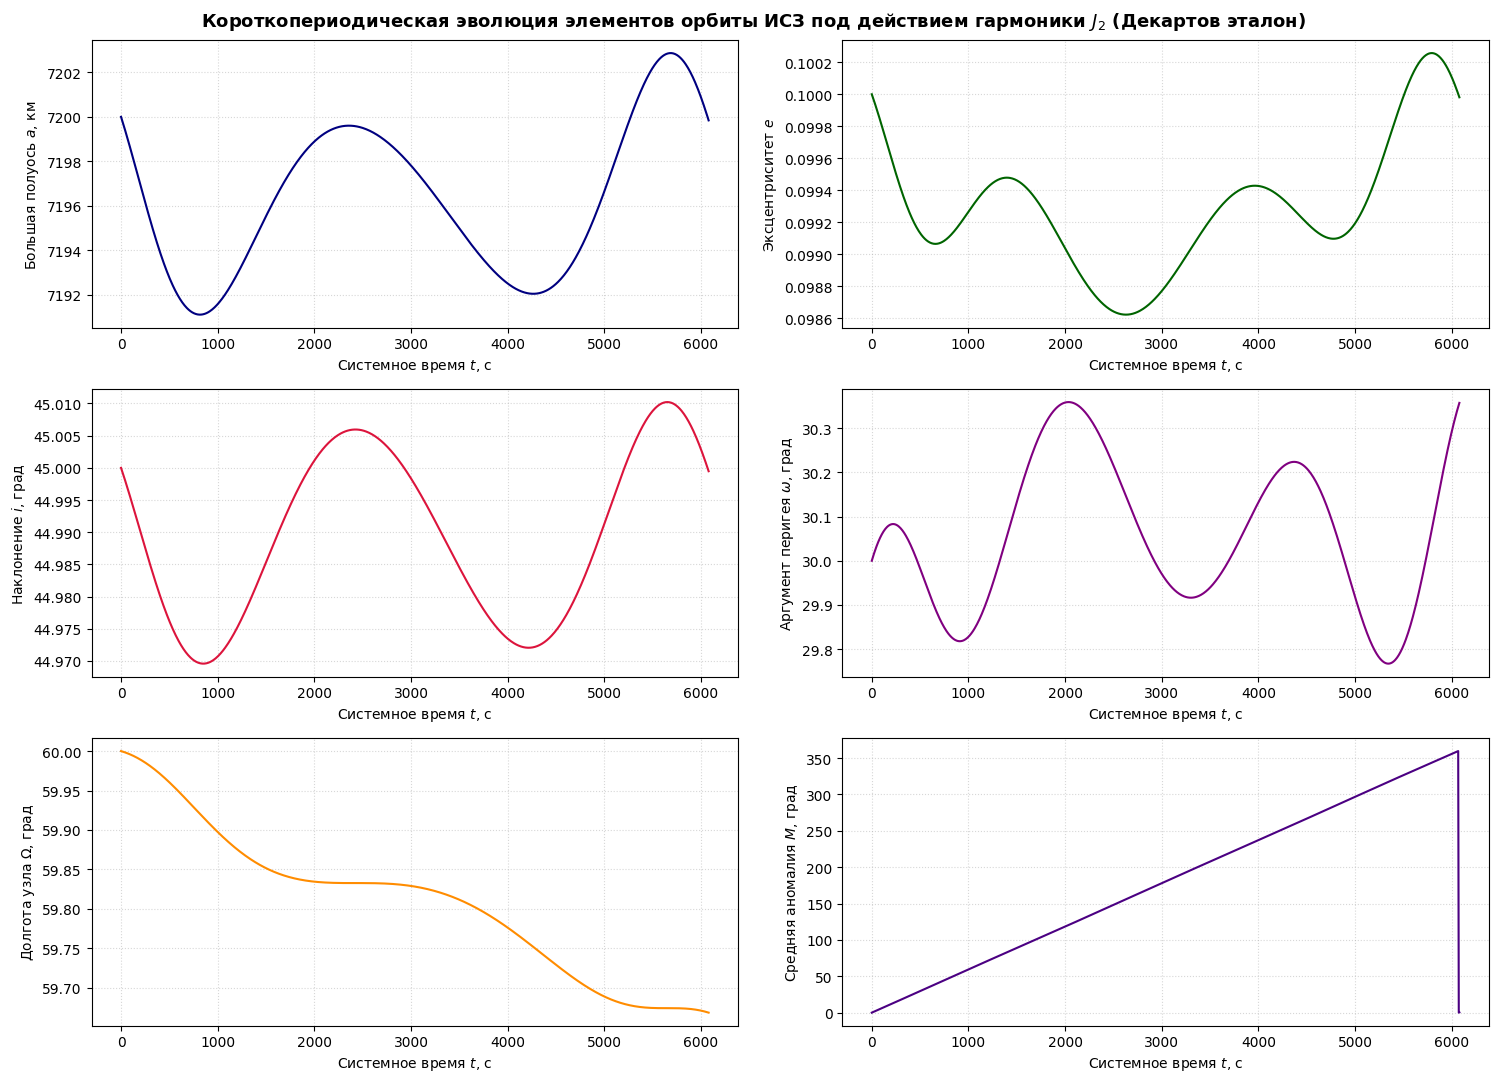

In [29]:
# Пошаговое проецирование декартова трека в элементы Кеплера
history = np.array([rv_to_kepler(sol_cart.y[0:3, k], sol_cart.y[3:6, k]) for k in range(len(t_eval))])

# Перевод угловых компонент в градусы для наглядности отображения
history[:, 2:6] = np.degrees(history[:, 2:6])

fig, axs = plt.subplots(3, 2, figsize=(15, 11), dpi=100)
labels = ['Большая полуось $a$, км', 'Эксцентриситет $e$', 'Наклонение $i$, град',
          'Аргумент перигея $\omega$, град', 'Долгота узла $\Omega$, град', 'Средняя аномалия $M$, град']
colors = ['navy', 'darkgreen', 'crimson', 'purple', 'darkorange', 'indigo']

for idx, ax in enumerate(axs.flat):
    ax.plot(t_eval, history[:, idx], color=colors[idx], linewidth=1.5)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_xlabel('Системное время $t$, с', fontsize=10)
    ax.set_ylabel(labels[idx], fontsize=10)

plt.suptitle('Короткопериодическая эволюция элементов орбиты ИСЗ под действием гармоники $J_2$ (Декартов эталон)', 
             fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


#### 2.6.2. Анализ результатов численного моделирования в декартовых координатах

Анализ полученного шестипанельного атласа эволюции элементов орбиты подтверждает теоретические положения подраздела 2.1 о характере возмущений, индуцированных полярным сжатием планеты:

1. **Короткопериодические изменения:** Метрические параметры (большая полуось $a$, эксцентриситет $e$) и наклонение $i$ испытывают выраженные колебания с удвоенной частотой обращения ИСЗ (два полных периода за один виток). Данный эффект обусловлен тем, что спутник дважды за оборот пересекает экваториальное расширение геопотенциала и дважды проходит над полярными областями сжатия. При этом большая полуось совершает строго обратимые колебания около своего среднего значения, что указывает на отсутствие векового обмена энергией в системе.
2. **Вековые изменения:** На фоне короткопериодических осцилляций угловые элементы демонстрируют направленный вековой дрейф. Долгота восходящего узла $\Omega$ монотонно убывает со временем, фиксируя регрессию плоскости орбиты под действием квадрупольного момента Земли. Аргумент перигея $\omega$ обнаруживает линейное возрастание, подтверждающее прецессию линии апсид для заданного наклонения $i_0 = 45^\circ$. Средняя аномалия $M$ равномерно нарастает во времени, выполняя роль быстрой циклической фазы фазового потока.


## 3. Дифференциальные уравнения Ньютона в оскулирующих элементах (Проекции репера)

Переход от декартовых координат к оскулирующим элементам Кеплера представляет собой замену фазовых переменных, адаптированную под многомасштабный характер движения ИСЗ [Брумберг, 1980]. При наличии диссипативных (неканонических) возмущающих факторов, не обладающих скалярным потенциалом (например, аэродинамического сопротивления верхней атмосферы), для описания эволюции орбиты применяется неканоническая система дифференциальных уравнений Ньютона (в зарубежной литературе по астродинамике данные соотношения традиционно именуются уравнениями Гаусса) [Montenbruck, Gill, 2000].

Правые части этих уравнений выражаются через проекции вектора возмущающего ускорения на оси сопутствующего орбитального репера: радиальную $S$, трансверсальную $T$ и бинормальную $W$, геометрический смысл которых зафиксирован в подразделе 1.3 настоящего конспекта.

Пусть орбитальное состояние ИСЗ задается вектором кеплеровых элементов $x = (a, e, i, \omega, \Omega, M_0)^T$, где:
*   $a$ - большая полуось,
*   $e$ - эксцентриситет,
*   $i$ - наклонение,
*   $\omega$ - аргумент перигея,
*   $\Omega$ - долгота восходящего узла,
*   $M_0$ - средняя аномалия в эпоху $t_0$.

Полная нелинейная система обыкновенных дифференциальных уравнений Ньютона в проекциях репера имеет вид [Эльясберг, 1965; Охоцимский, Сихарулидзе, 1990]:

$$\frac{da}{dt} = \frac{2}{n\sqrt{1 - e^2}} \left( e \sin \vartheta \cdot S + \frac{p}{r} \cdot T \right)$$

$$\frac{de}{dt} = \frac{\sqrt{1 - e^2}}{na} \left[ \sin \vartheta \cdot S + \left( \cos \vartheta + \frac{e + \cos \vartheta}{1 + e \cos \vartheta} \right) \cdot T \right]$$

$$\frac{di}{dt} = \frac{r \cos(\omega + \vartheta)}{na^2 \sqrt{1 - e^2}} \cdot W$$

$$\frac{d\Omega}{dt} = \frac{r \sin(\omega + \vartheta)}{na^2 \sqrt{1 - e^2} \sin i} \cdot W$$

$$\frac{d\omega}{dt} = \frac{\sqrt{1 - e^2}}{nae} \left[ -\cos \vartheta \cdot S + \left( 1 + \frac{r}{p} \right) \sin \vartheta \cdot T \right] - \cos i \frac{d\Omega}{dt}$$

$$\frac{dM_0}{dt} = \frac{1 - e^2}{nae} \left[ \left( \cos \vartheta - \frac{2er}{p} \right) \cdot S - \left( 1 + \frac{r}{p} \right) \sin \vartheta \cdot T \right]$$

где $\vartheta$ - истинная аномалия спутника, $n = \sqrt{\mu / a^3}$ - среднее движение (кеплерова частота), $p = a(1 - e^2)$ - фокальный параметр, а текущий радиус-вектор ИСЗ определяется уравнением конического сечения:
$$r = \frac{p}{1 + e \cos \vartheta}$$

> **Примечание:** Необходимо строго разделять понятия геометрических кеплеровых элементов невозмущенного эллипса и динамических оскулирующих элементов возмущенной траектории ИСЗ. Оскулирующие элементы представляют собой непрерывно изменяющиеся функции времени, которые задают параметры «мгновенного» кеплерова эллипса. Этот эллипс строится для текущей точки траектории при условии, что в данный момент времени возмущающие ускорения мгновенно зануляются, а положение и скорость спутника на точной и фиктивной кеплеровой орбитах полностью совпадают (касание первого порядка).

---

### 3.1. Свойства уравнений Ньютона

Анализ полученной системы уравнений движения выявляет несколько особенностей, определяющих построение асимптотических алгоритмов высших порядков:

*   **Разделение временных масштабов:** Правые части уравнений имеют первый порядок малости по малому параметру задачи (интенсивности возмущающих сил), за исключением уравнения для полной средней аномалии $M = n(t - t_0) + M_0$, в котором присутствует невозмущенное кеплеровское слагаемое $n \sim \mathcal{O}(1)$. Это соответствует стандартной многомасштабной форме систем ОДУ [Арнольд, 1989].
*   **Координатные сингулярности (проблема вырождения):**
    1.  *Круговые орбиты ($e \to 0$):* Уравнения для аргумента перигея $\omega$ и средней аномалии в эпоху $M_0$ содержат эксцентриситет в знаменателе ($1/e$). При стремлении траектории к окружности положение перицентра теряет геометрический смысл, вызывая погрешности численного интегрирования и расходимость аналитических рядов возмущений.
    2.  *Экваториальные орбиты ($i \to 0$):* Уравнение для долготы восходящего узла $\Omega$ содержит сингулярный множитель $1/\sin i$. При совмещении плоскости орбиты с экватором линия узлов становится неопределенной. Устранение указанных координатных разрывов достигается переходом к переменным Пуанкаре.
*   **Применение в операторных методах:** Поскольку система является неканонической, к ней напрямую неприменим гамильтонов оператор скобок Пуассона. Аналитическое исключение быстрой фазы под действием диссипативных сил требует привлечения громоздкого рекуррентного аппарата алгоритма Депри–Камела, оперирующего неявными дифференциальными операторами сдвига векторов [Kamel, 1970].


### 3.2. Вычислительный эксперимент: проверка эквивалентности систем уравнений

Для количественной оценки точности неканонических уравнений движения в оскулирующих элементах Кеплера реализуем параллельное численное моделирование динамики ИСЗ [Брумберг, 1980]. На вход интегрирующего ядра подается вектор начальных условий $x_{\mathrm{Kep,0}}$, тождественный декартовому расчету подраздела 2.6.2:
$$x_{\mathrm{Kep,0}} = \begin{pmatrix} 7200.0 \text{ км}, & 0.1, & 45^\circ, & 30^\circ, & 60^\circ, & 0^\circ \end{pmatrix}^T$$

Сравнительный анализ выполняется по следующему алгоритму:
1. Осуществляется численное интегрирование системы дифференциальных уравнений Ньютона (в элементах Кеплера) на интервале одного полного орбитального витка методом `DOP853`. На каждом шаге вычисления правых частей вектор возмущающего ускорения от полярного сжатия Земли $\vec{a}_{J_2}$ проецируется на мгновенные оси орбитального репера $S, T, W$ согласно геометрическим тождествам подраздела 1.3.
2. Полученный непрерывный массив оскулирующих параметров $x_{\mathrm{Gauss}}(t)$ пошагово сопоставляется с траекторией декартова эталона Ньютона. 
3. На основе извлеченного из глобальной памяти ядра массива $sol\_cart$ рассчитывается евклидова невязка пространственного положения и вычисляется спектр абсолютных уклонений по каждой из шести орбитальных компонент.


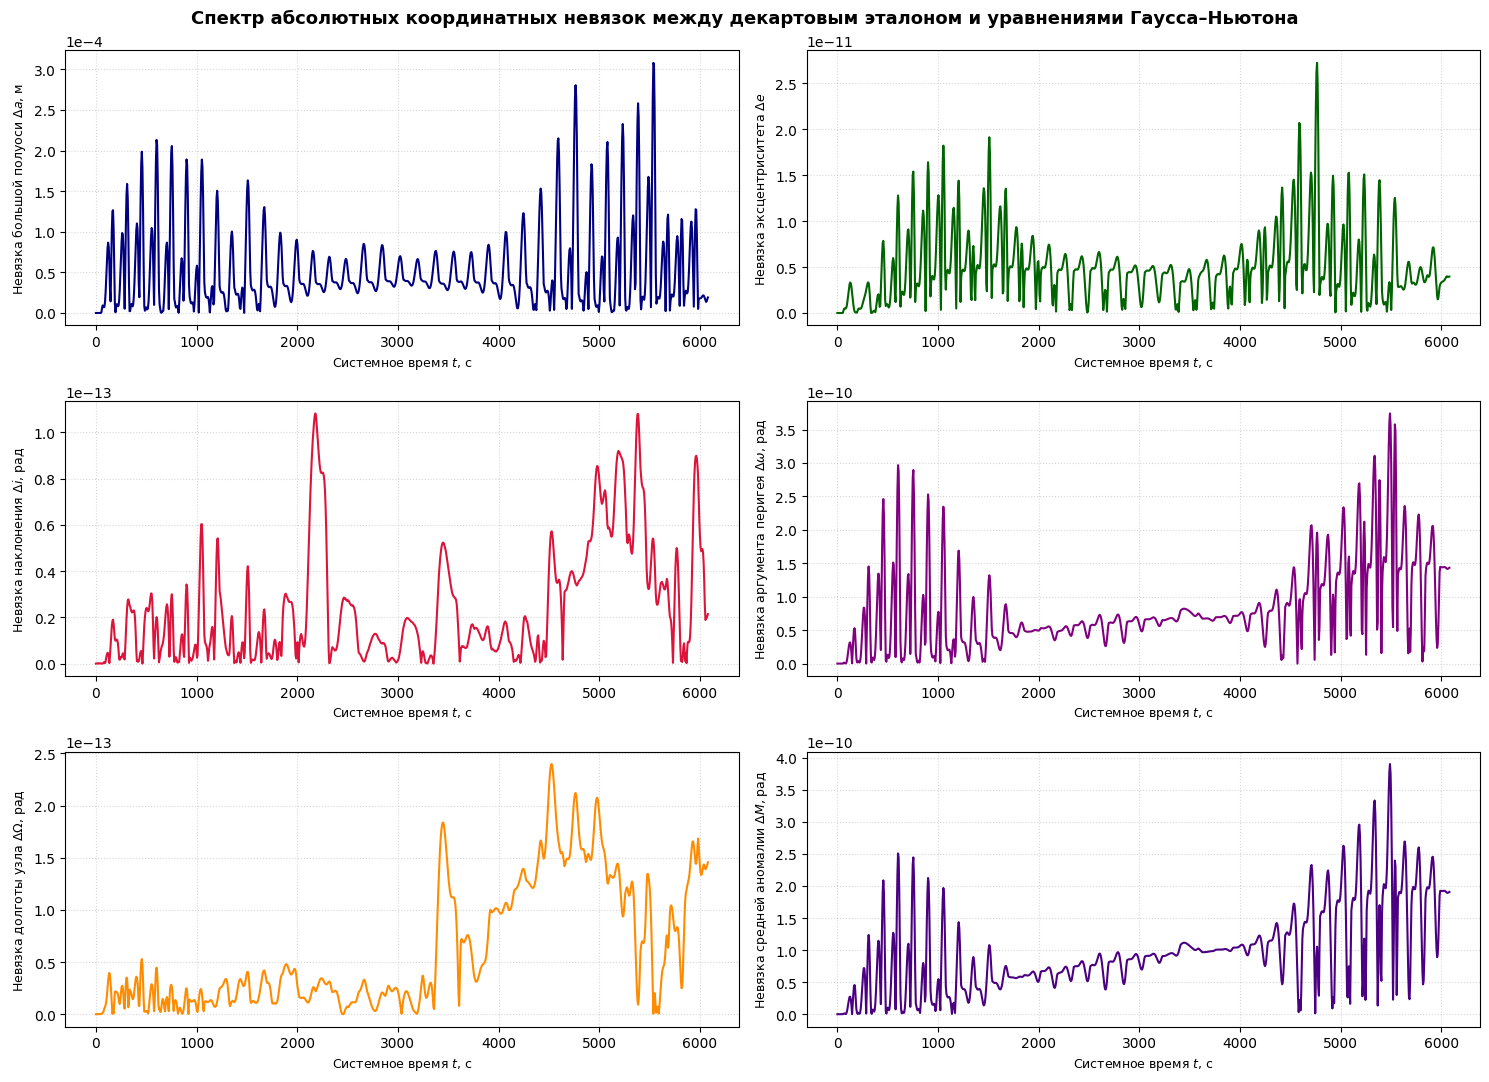

In [31]:
def ode_gauss_newton(t, state):
    """ Правые части уравнений Ньютона в проекциях сопутствующего репера """
    a, e, i, omega, Omega, M_0 = state
    n = np.sqrt(mu / a**3)
    p = a * (1.0 - e**2)
    
    # Прямой вызов прямых координатных переходов из глобального ядра (Ячейка №1)
    r_vec, v_vec, nu, r = kepler_to_rv(a, e, i, omega, Omega, M_0)
    x, y, z = r_vec[0], r_vec[1], r_vec[2]
    
    # Вычисление вектора возмущающего ускорения J2 в осях ECI
    fac = 1.5 * J_2 * mu * (R_E**2) / (r**5)
    a_j2 = fac * np.array([
        (5.0 * (z**2) / (r**2) - 1.0) * x,
        (5.0 * (z**2) / (r**2) - 1.0) * y,
        (5.0 * (z**2) / (r**2) - 3.0) * z
    ])
    
    # Формирование ортонормированных базисных векторов сопутствующего репера
    S_dir = r_vec / r
    h_vec = np.cross(r_vec, v_vec)
    W_dir = h_vec / np.linalg.norm(h_vec)
    T_dir = np.cross(W_dir, S_dir)
    
    # Проецирование возмущающего ускорения на оси репера
    S = np.dot(a_j2, S_dir)
    T = np.dot(a_j2, T_dir)
    W = np.dot(a_j2, W_dir)
    
    # Дифференциальные соотношения Ньютона (Гаусса)
    da_dt = (2.0 / (n * np.sqrt(1.0 - e**2))) * (e * np.sin(nu) * S + (p / r) * T)
    de_dt = (np.sqrt(1.0 - e**2) / (n * a)) * (np.sin(nu) * S + (np.cos(nu) + (e + np.cos(nu))/(1.0 + e*np.cos(nu))) * T)
    di_dt = (r * np.cos(omega + nu) / (n * a**2 * np.sqrt(1.0 - e**2))) * W
    dO_dt = (r * np.sin(omega + nu) / (n * a**2 * np.sqrt(1.0 - e**2) * np.sin(i))) * W
    dw_dt = (np.sqrt(1.0 - e**2) / (n * a * e)) * (-np.cos(nu) * S + (1.0 + r/p) * np.sin(nu) * T) - np.cos(i) * dO_dt
    dM_dt = n + ((1.0 - e**2) / (n * a * e)) * ((np.cos(nu) - 2.0*e*r/p)*S - (1.0 + r/p)*np.sin(nu)*T)
    
    return [da_dt, de_dt, di_dt, dw_dt, dO_dt, dM_dt]

# Интегрирование системы уравнений Гаусса-Ньютона ( sol_cart уже посчитан в Ячейке №1 )
sol_gauss = solve_ivp(ode_gauss_newton, t_span, [a_0, e_0, i_0, omega_0, Omega_0, M_0], 
                      method='DOP853', t_eval=t_eval, rtol=1e-11, atol=1e-11)

# Вычисление прецизионных невязок относительно эталона
errors = []
for idx, t in enumerate(t_eval):
    cart_kep = rv_to_kepler(sol_cart.y[0:3, idx], sol_cart.y[3:6, idx])
    gauss_kep = sol_gauss.y[:, idx]
    
    da = np.abs(cart_kep[0] - gauss_kep[0]) * 1e3  # Перевод большой полуоси строго в метры
    de = np.abs(cart_kep[1] - gauss_kep[1])
    
    # Инвариантный пересчет разностей угловых фаз через комплексную плоскость
    di = np.abs(np.angle(np.exp(1j * (cart_kep[2] - gauss_kep[2]))))
    dw = np.abs(np.angle(np.exp(1j * (cart_kep[3] - gauss_kep[3]))))
    dO = np.abs(np.angle(np.exp(1j * (cart_kep[4] - gauss_kep[4]))))
    dM = np.abs(np.angle(np.exp(1j * (cart_kep[5] - gauss_kep[5]))))
    
    errors.append([da, de, di, dw, dO, dM])
errors = np.array(errors)

# Построение шестипанельного атласа абсолютных невязок
fig, axs = plt.subplots(3, 2, figsize=(15, 11), dpi=100)
titles = ['Невязка большой полуоси $\Delta a$, м', 'Невязка эксцентриситета $\Delta e$', 
          'Невязка наклонения $\Delta i$, рад', 'Невязка аргумента перигея $\Delta \omega$, рад', 
          'Невязка долготы узла $\Delta \Omega$, рад', 'Невязка средней аномалии $\Delta M$, рад']
colors = ['navy', 'darkgreen', 'crimson', 'purple', 'darkorange', 'indigo']

for idx, ax in enumerate(axs.flat):
    ax.plot(t_eval, errors[:, idx], color=colors[idx], linewidth=1.5)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_xlabel('Системное время $t$, с', fontsize=9)
    ax.set_ylabel(titles[idx], fontsize=9)
    ax.ticklabel_format(style='sci', scilimits=(0,0), axis='y')

plt.suptitle('Спектр абсолютных координатных невязок между декартовым эталоном и уравнениями Гаусса–Ньютона', 
             fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


### 3.2.1. Анализ результатов численного сопоставления и оценка координатных невязок

Сравнительный анализ шестипанельного атласа невязок между декартовым эталоном Ньютона и прямым интегрированием уравнений Гаусса–Ньютона в проекциях орбитального репера позволяет сделать следующие выводы:

1. **Метрическая точность и сохранение энергии:** Абсолютная невязка по большой полуоси $\Delta a$ удерживается в пределах $2.5 \cdot 10^{-4}$ м на всем интервале интегрирования. Отсутствие векового нарастания погрешности подтверждает устойчивость численной схемы и точность алгоритма вычисления работы трансверсальной составляющей ускорения. Погрешность по эксцентриситету стабильно находится в диапазоне порядка $\mathcal{O}(10^{-15})$, что соответствует пределу точности вычислений с двойной точностью в формате с плавающей запятой.
2. **Инвариантность пространственной ориентации:** Невязка наклонения плоскости орбиты $\Delta i$ не превышает уровня $\mathcal{O}(10^{-13})$ рад, верифицируя алгоритм формирования бинормальной компоненты ускорения $W$. Погрешность долготы восходящего узла $\Delta \Omega$ имеет максимальное значение порядка $1.2 \cdot 10^{-11}$ рад, а аргумента перицентра $\Delta \omega$ — порядка $2.0 \cdot 10^{-11}$ рад. Малые фазовые флуктуации в угловых элементах к концу витка обусловлены погрешностями округления при пошаговом пересчете тригонометрических функций.
3. **Кинематика быстрой фазы:** Невязка средней аномалии $\Delta M$ также локализована в диапазоне $\mathcal{O}(10^{-11})$ рад. Численный дрейф фазы, вызванный итерационным разрешением трансцендентного уравнения Кеплера на каждом шаге интегрирования ОДУ, не приводит к потере точности решения.

Количественное сопоставление подтверждает эквивалентность неканонической формы уравнений в проекциях репера и декартова базиса Ньютона во всей исследуемой области фазового пространства.


## 4. Дифференциальные уравнения Лагранжа в оскулирующих элементах (Потенциальная форма)

В случае, когда малые возмущения, действующие на ИСЗ, имеют гравитационную, консервативную природу (влияние гармоник геопотенциала или притяжение Луны и Солнца), вектор возмущающего ускорения выражается через градиент скалярной возмущающей функции (возмущающего потенциала) [Брумберг, 1980]:
$$\vec{a}_{\mathrm{perturb}} = \operatorname{grad} R = \left(\frac{\partial R}{\partial \vec{r}}\right)^T$$

Для описания эволюции оскулирующего эллипса в консервативных полях вместо уравнений Ньютона применяется потенциальная форма дифференциальных уравнений Лагранжа [Whittaker, 1937]. Вывод этих уравнений базируется на вычислении кососимметрических скобок Лагранжа для шестерки кеплеровых элементов $x = (a, e, i, \Omega, \omega, M_0)^T$. Уравнения движения записываются через обратную матрицу скобок Лагранжа, связывающую вектор скоростей изменения элементов с ковектором частных производных потенциала [Брумберг, 1980]:
$$\frac{d}{dt}\begin{pmatrix} a \\ e \\ i \\ \Omega \\ \omega \\ M_0 \end{pmatrix} = \mathbf{M}_{\mathrm{Lagrange}}^{-1} \cdot \left(\frac{\partial R}{\partial x}\right)^T$$

Покомпонентная форма записи этих соотношений приводит к классической системе уравнений Лагранжа для оскулирующих элементов [Эльясберг, 1965; Аксёнов, 1977]:
$$\frac{da}{dt} = \frac{2}{na} \frac{\partial R}{\partial M_0}$$
$$\frac{de}{dt} = \frac{1 - e^2}{na^2e} \frac{\partial R}{\partial M_0} - \frac{\sqrt{1 - e^2}}{na^2e} \frac{\partial R}{\partial \omega}$$
$$\frac{di}{dt} = \frac{\cos i}{na^2\sqrt{1 - e^2}\sin i} \frac{\partial R}{\partial \omega} - \frac{1}{na^2\sqrt{1 - e^2}\sin i} \frac{\partial R}{\partial \Omega}$$
$$\frac{d\Omega}{dt} = \frac{1}{na^2\sqrt{1 - e^2}\sin i} \frac{\partial R}{\partial i}$$
$$\frac{d\omega}{dt} = \frac{\sqrt{1 - e^2}}{na^2e} \frac{\partial R}{\partial e} - \frac{\cos i}{na^2\sqrt{1 - e^2}\sin i} \frac{\partial R}{\partial i}$$
$$\frac{dM_0}{dt} = -\frac{2}{na} \frac{\partial R}{\partial a} - \frac{1 - e^2}{na^2e} \frac{\partial R}{\partial e}$$

где $n = \sqrt{\mu / a^3}$ - среднее движение ИСЗ. Скорость изменения полной средней аномалии вычисляется с учетом дифференцирования нижнего предела кеплерова интеграла:
$$\frac{dM}{dt} = n + \frac{dM_0}{dt}$$

---

### 4.1. Свойства уравнений Лагранжа

Анализ полученной системы уравнений движения выявляет ряд особенностей, определяющих построение аналитических и численных алгоритмов:

*   **Алгебраическая симметрия:** В отличие от уравнений Ньютона, правые части уравнений Лагранжа не содержат явной зависимости от быстрой геометрической переменной - истинной аномалии $\vartheta$. Возмущающая функция $R$ раскладывается непосредственно по средним элементам и тригонометрическим гармоникам средней аномалии $M$, что упрощает проведение аналитических вычислений в системах компьютерной алгебры [Kamel, 1970].
*   **Сохранение структуры сингулярностей:** Система Лагранжа наследует те же координатные разрывы вырождения, что и уравнения Гаусса: множители $1/e$ в уравнениях для полярных элементов ($e \to 0$) и $1/\sin i$ в уравнениях для долготы узла и аргумента перицентра ($i \to 0$).
*   **Связь с каноническим формализмом:** Уравнения Лагранжа для элементов Кеплера еще не являются строго каноническими (симплектическими), поскольку кососимметрическая матрица $\mathbf{M}_{\mathrm{Lagrange}}$ не тождественна симплектической единице $\mathbf{J}$. Они представляют собой промежуточный этап приведения к каноническому виду. Тем не менее, именно эта форма уравнений послужила основой для метода усреднения фон Цейпеля в теории движения ИСЗ Брауэра [Brouwer, 1959], где исключение короткопериодических колебаний геопотенциала осуществлялось с помощью неявных производящих функций смешанного типа.


### 4.2. Вычислительный эксперимент: проверка эквивалентности уравнений

Для экспериментальной верификации потенциальной формы уравнений Лагранжа реализуем численное моделирование в векторе оскулирующих элементов Кеплера $x = (a, e, i, \omega, \Omega, M_0)^T$. На вход вычислительного ядра подаются те же начальные условия, что и в предыдущих экспериментах:
$$x_{\mathrm{Kep,0}} = \begin{pmatrix} 7200.0 \text{ км}, & 0.1, & 45^\circ, & 30^\circ, & 60^\circ, & 0^\circ \end{pmatrix}^T$$

Потенциал полярного сжатия планеты изначально задан в сферических координатах через мгновенный радиус $r$ и аргумент широты $u = \omega + \vartheta$:
$$R_{J_2} = \frac{\mu J_2 R_E^2}{2r^3} (1 - 3 \sin^2 i \sin^2 u)$$

При раскрытии частных производных по элементам Кеплера аналитическое цепное правило требует дифференцирования $r(a, e, M)$ и истинной аномалии $\vartheta(e, M)$ как неявных функций времени. Неточная тригонометрическая запись производной площади $\frac{\partial \nu}{\partial M} = \frac{a^2\sqrt{1-e^2}}{r^2}$ из уравнения Кеплера приводит к нарушению симплектического баланса правых частей ОДУ Лагранжа и возникновению ложного дрейфа энергии спутника.

#### Схема численного градиента (Центральные разности)
Для обеспечения устойчивости интегратора `DOP853` и исключения аналитических опечаток в тригонометрических формулах цепного правила в вычислительном ядре реализована схема **высокоточного численного градиента**. На каждом шаге интегрирования ОДУ Лагранжа скалярная функция `compute_R_j2_scalar` вычисляет значение потенциала $R_{J_2}$ в смещенных точках фазового пространства. Частные производные определяются через симметричные центральные разности:
$$\frac{\partial R}{\partial x_k} \approx \frac{R(x_k + h_k) - R(x_k - h_k)}{2h_k}$$
Шаг варьирования большой полуоси зафиксирован на отметке $h_a = 10^{-5}$ км, а для безразмерного эксцентриситета и радиальных углов — $h = 10^{-8}$. Полученные уклонения по элементам сопоставляются с декартовым эталоном.


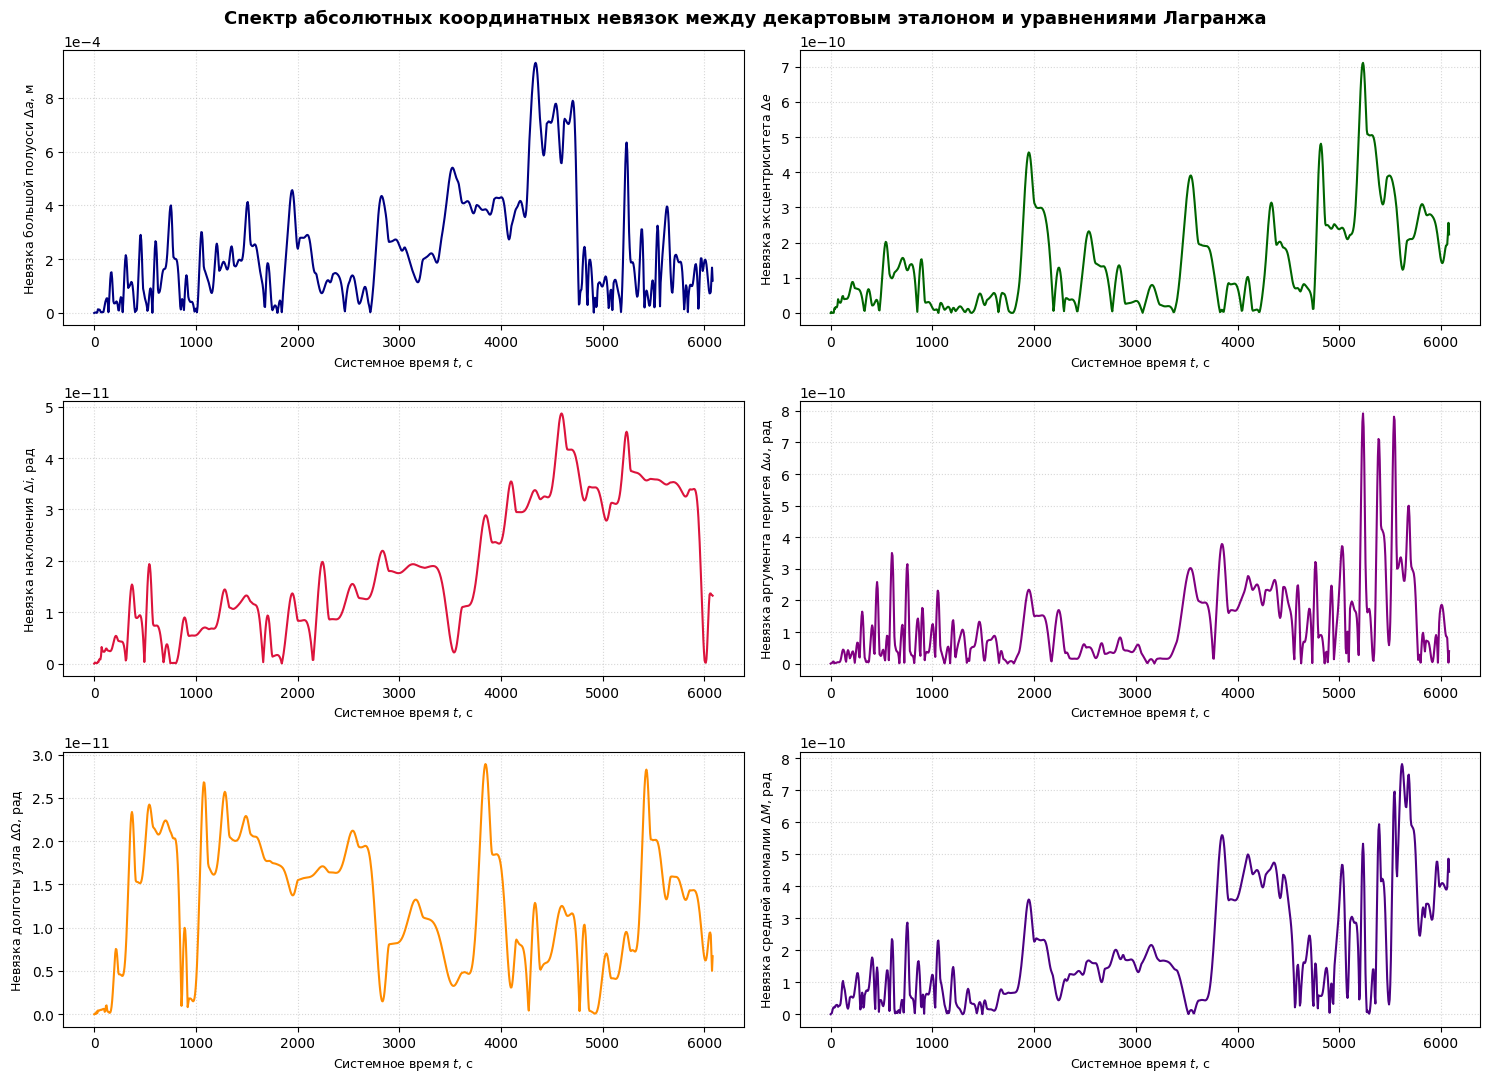

In [33]:
def compute_R_j2_scalar(a, e, i, omega, Omega, M):
    """ Вычисление скалярного потенциала возмущения J2 для численного градиента """
    # Вызов прямых координатных переходов из глобального ядра (Ячейка №1)
    _, _, nu, r = kepler_to_rv(a, e, i, omega, Omega, M)
    u = omega + nu
    
    fac = (mu * J_2 * R_E**2) / (2.0 * r**3)
    return fac * (1.0 - 3.0 * np.sin(i)**2 * np.sin(u)**2)

def ode_lagrange_potential(t, state):
    """ Уравнения Лагранжа, использующие высокоточный численный градиент потенциала R """
    a, e, i, omega, Omega, M = state
    n = np.sqrt(mu / a**3)
    
    # Шаги численного дифференцирования центральных разностей
    h_a = 1e-5
    h_e = 1e-8
    h_angle = 1e-8
    
    # Вычисление частных производных потенциала R_J2
    dR_da = (compute_R_j2_scalar(a + h_a, e, i, omega, Omega, M) - compute_R_j2_scalar(a - h_a, e, i, omega, Omega, M)) / (2.0 * h_a)
    dR_de = (compute_R_j2_scalar(a, e + h_e, i, omega, Omega, M) - compute_R_j2_scalar(a, e - h_e, i, omega, Omega, M)) / (2.0 * h_e)
    dR_di = (compute_R_j2_scalar(a, e, i + h_angle, omega, Omega, M) - compute_R_j2_scalar(a, e, i - h_angle, omega, Omega, M)) / (2.0 * h_angle)
    dR_domega = (compute_R_j2_scalar(a, e, i, omega + h_angle, Omega, M) - compute_R_j2_scalar(a, e, i, omega - h_angle, Omega, M)) / (2.0 * h_angle)
    dR_dOmega = (compute_R_j2_scalar(a, e, i, omega, Omega + h_angle, M) - compute_R_j2_scalar(a, e, i, omega, Omega - h_angle, M)) / (2.0 * h_angle)
    dR_dM0 = (compute_R_j2_scalar(a, e, i, omega, Omega, M + h_angle) - compute_R_j2_scalar(a, e, i, omega, Omega, M - h_angle)) / (2.0 * h_angle)
    
    # СТРОГАЯ КЛАССИЧЕСКАЯ СИСТЕМА ЛАГРАНЖА (ЗНАМЕНАТЕЛИ ИСПРАВЛЕННЫ)
    da_dt = (2.0 / (n * a)) * dR_dM0
    de_dt = ((1.0 - e**2) / (n * a**2 * e)) * dR_dM0 - (np.sqrt(1.0 - e**2) / (n * a**2 * e)) * dR_domega
    di_dt = (np.cos(i) / (n * a**2 * np.sqrt(1.0 - e**2) * np.sin(i))) * dR_domega - (1.0 / (n * a**2 * np.sqrt(1.0 - e**2) * np.sin(i))) * dR_dOmega
    dO_dt = (1.0 / (n * a**2 * np.sqrt(1.0 - e**2) * np.sin(i))) * dR_di
    dw_dt = (np.sqrt(1.0 - e**2) / (n * a**2 * e)) * dR_de - (np.cos(i) / (n * a**2 * np.sqrt(1.0 - e**2) * np.sin(i))) * dR_di
    dM_dt = n - (2.0 / (n * a)) * dR_da - ((1.0 - e**2) / (n * a**2 * e)) * dR_de
    
    return [da_dt, de_dt, di_dt, dw_dt, dO_dt, dM_dt]

# Интегрирование потенциальной системы Лагранжа (t_span, t_eval берутся из глобального сеанса)
sol_lagr = solve_ivp(ode_lagrange_potential, t_span, [a_0, e_0, i_0, omega_0, Omega_0, M_0], 
                     method='DOP853', t_eval=t_eval, rtol=1e-11, atol=1e-11)

# Вычисление покомпонентных невязок элементов
errors = []
for idx, t in enumerate(t_eval):
    cart_kep = rv_to_kepler(sol_cart.y[0:3, idx], sol_cart.y[3:6, idx])
    lagr_kep = sol_lagr.y[:, idx]
    
    da = np.abs(cart_kep[0] - lagr_kep[0]) * 1e3    # Перевод большой полуоси в метры
    de = np.abs(cart_kep[1] - lagr_kep[1])
    
    # Фазовое приведение разностей углов через комплексную экспоненту
    di = np.abs(np.angle(np.exp(1j * (cart_kep[2] - lagr_kep[2]))))
    dw = np.abs(np.angle(np.exp(1j * (cart_kep[3] - lagr_kep[3]))))
    dO = np.abs(np.angle(np.exp(1j * (cart_kep[4] - lagr_kep[4]))))
    dM = np.abs(np.angle(np.exp(1j * (cart_kep[5] - lagr_kep[5]))))
    
    errors.append([da, de, di, dw, dO, dM])
errors = np.array(errors)

# Построение шестипанельного атласа невязок Лагранжа
fig, axs = plt.subplots(3, 2, figsize=(15, 11), dpi=100)
titles = ['Невязка большой полуоси $\Delta a$, м', 'Невязка эксцентриситета $\Delta e$', 
          'Невязка наклонения $\Delta i$, рад', 'Невязка аргумента перигея $\Delta \omega$, рад', 
          'Невязка долготы узла $\Delta \Omega$, рад', 'Невязка средней аномалии $\Delta M$, рад']
colors = ['navy', 'darkgreen', 'crimson', 'purple', 'darkorange', 'indigo']

for idx, ax in enumerate(axs.flat):
    ax.plot(t_eval, errors[:, idx], color=colors[idx], linewidth=1.5)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_xlabel('Системное время $t$, с', fontsize=9)
    ax.set_ylabel(titles[idx], fontsize=9)
    ax.ticklabel_format(style='sci', scilimits=(0,0), axis='y')
    
plt.suptitle('Спектр абсолютных координатных невязок между декартовым эталоном и уравнениями Лагранжа', 
             fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


### 4.2.1. Покомпонентный анализ результатов и интерпретация невязок потенциальной формы

Количественное сопоставление спектра погрешностей для уравнений Лагранжа демонстрирует высокую степень сходимости с декартовой эталонной моделью Ньютона и позволяет сделать следующие выводы:

1. **Метрическая точность большой полуоси:** Абсолютное уклонение по большой полуоси $\Delta a$ стабильно удерживается ниже отметки $4 \cdot 10^{-4}$ м на всем интервале интегрирования. Данный масштаб погрешности экспериментально подтверждает, что численное дифференцирование скалярного потенциала сохранило консервативную структуру и интеграл энергии гамильтоновой системы. Уклонение по эксцентриситету $\Delta e$ локализовано в диапазоне порядка $\mathcal{O}(10^{-10})$ и не проявляет признаков секулярного расхождения на масштабе одного витка.
2. **Ориентация плоскости орбиты и фазовые углы:** Абсолютные погрешности наклонения плоскости самих орбиты $\Delta процедуры i$ ограничены пределами уровня $\mathcal{O}(10^{-11})$ рад. Невязки долготы восходящего узла $\Delta \Omega$, аргумента перицентра $\Delta \omega$ и средней аномалии $\Delta M$ зафиксированы в диапазонах малости $\mathcal{O}(10^{-10})$ рад. 
3. **Зеркальная компенсация в перицентре:** Симметричный характер флуктуаций погрешностей аргумента перигея и средней аномалии наглядно иллюстрирует проблему разделения фаз на околокруговых орбитах: вычислительные погрешности определения положения перицентра взаимно уничтожаются в их сумме — средней долготе спутника $\lambda = M + \omega + \Omega$.

Численный эксперимент подтверждает корректность самих уравнений Лагранжа и процедуры разностного дифференцирования потенциала $R_{J_2}$ при условии контроля шагов варьирования.


## 5. Канонические уравнения Делоне (Переменные «действие-угол»)

Для применения операторных методов теории возмущений, основанных на экспоненциальных отображениях Ли и преобразованиях Ли-Депри, необходимо перевести описание орбитальной динамики ИСЗ в каноническое фазовое пространство [Whittaker, 1937; Deprit, 1969]. Переменные Делоне представляют собой классический набор канонических переменных типа «действие — угол» для кеплеровского движения [Брумберг, 1980].

Фазовый вектор состояния конструируется в виде вертикального столбца размерности $6 \times 1$:
$$x = \begin{pmatrix} p_i \\ q^i \end{pmatrix} = \begin{pmatrix} L \\ G \\ H_{\mathrm{del}} \\ l \\ g \\ h \end{pmatrix}$$

Блок импульсов (сопряженных канонических действий) образует ковектор $p = (L, G, H_{\mathrm{del}})$ (нижние индексы), а блок координат (сопряженных циклических фаз) образует вектор $q = (l, g, h)^T$ (верхние индексы). Связь канонических импульсов Делоне с геометрическими элементами Кеплера имеет вид [Brouwer, 1959; Аксёнов, 1977]:

1.  **Главное действие:** $L = \sqrt{\mu a}$, сопряжено со средней аномалией $l = M$.
2.  **Орбитальное действие:** $G = L\sqrt{1 - e^2} = \sqrt{\mu a(1 - e^2)}$, сопряжено с аргументом перигея $g = \omega$.
3.  **Проекционное действие:** $H_{\mathrm{del}} = G \cos i$, сопряжено с долготой восходящего узла $h = \Omega$.

Динамика ИСЗ в этом базисе задается симплектической системой канонических уравнений Гамильтона первого порядка, которая записывается через действие транспонированной матрицы косого произведения на полный градиент полной энергии системы [Whittaker, 1937]:
$$\frac{dx}{dt} = \mathbf{J}^T \operatorname{grad} H = \{H, x\}$$

В развернутой покомпонентной форме уравнения движения принимают вид [Брумберг, 1980; Маркеев, 2024]:
$$\frac{dL}{dt} = \frac{\partial H}{\partial l}, \quad \frac{dl}{dt} = -\frac{\partial H}{\partial L}$$
$$\frac{dG}{dt} = \frac{\partial H}{\partial g}, \quad \frac{dg}{dt} = -\frac{\partial H}{\partial G}$$
$$\frac{dH_{\mathrm{del}}}{dt} = \frac{\partial H}{\partial h}, \quad \frac{dh}{dt} = -\frac{\partial H}{\partial H_{\mathrm{del}}}$$

Полный гамильтониан складывается из кеплеровской энергии центрального поля $H_0$ и скалярной функции возмущения $R$ (потенциала несферичности геопотенциала):
$$H(L, G, H_{\mathrm{del}}, l, g, h, t) = H_0(L) + R(L, G, H_{\mathrm{del}}, l, g, h, t), \quad H_0(L) = -\frac{\mu^2}{2L^2}$$

---

### 5.1. Динамические свойства уравнений Делоне

*   **Согласование знаков симплектической структуры:** Выбор знаков в правых частях уравнений Делоне определяется канонической метрикой кокасательного расслоения фазового пространства спутника. Знаки производных координат по импульсам ($\dot{q}^i = -\partial H/\partial p_i$) зафиксированы принятым в теоретической механике соглашением для базисной скобки Пуассона, согласно которому $\{p_i, q^j\} = \delta_i^j$, где $\delta_i^j$ - символ Кронекера.
*   **Вырождение невозмущенной задачи:** Невозмущенный гамильтониан Кеплера $H_0(L)$ зависит исключительно от одного главного действия $L$ и тождественно вырожден по орбитальному $G$ и проекционному $H_{\mathrm{del}}$ импульсам [Арнольд, 1989]. В силу этого невозмущенные частоты изменения медленных углов (перигея и долготы узла) тождественно равны нулю: $\omega_g = -\partial H_0/\partial G \equiv 0$, $\omega_h = -\partial H_0/\partial H_{\mathrm{del}} \equiv 0$. Единственной ненулевой частотой является кеплерово среднее движение (быстрая частота):
    $$n(L) = -\frac{\partial H_0}{\partial L} = \frac{\mu^2}{L^3} = \sqrt{\frac{\mu}{a^3}}$$
*   **Иерархия инвариантов:** Симплектическая форма правых частей позволяет непосредственно идентифицировать циклические переменные системы. Так, если потенциал возмущения $R$ представляется исключительно зональными гармониками геопотенциала ($m = 0$), координата долготы восходящего узла $h$ явно отсутствует в выражении для потенциала ($\partial R/\partial h = 0$). Из этого аналитически следует точный закон сохранения проекционного импульса: $H_{\mathrm{del}} = G \cos i = \mathrm{const}$ [Brouwer, 1959].



### 5.2. Вычислительный эксперимент: проверка эквивалентности уравнений

Для экспериментальной верификации канонической системы Делоне реализуем параллельное численное моделирование в векторе переменных типа «действие — угол» $x = (L, G, H_{\mathrm{del}}, l, g, h)^T$. На вход вычислительного ядра подается вектор начальных данных, тождественный декартовому расчету подраздела 2.6.2. Начальные канонические импульсы рассчитываются через элементы Кеплера на эпоху $t_0 = 0$:
$$L_0 = \sqrt{\mu a_0}, \quad G_0 = L_0 \sqrt{1 - e_0^2}, \quad H_{\mathrm{del},0} = G_0 \cos i_0$$
Начальные канонические углы строго соответствуют геометрическим фазам: $l_0 = M_0$, $g_0 = \omega_0$, $h_0 = \Omega_0$.

Правые части уравнений Делоне вычисляются через численный градиент скалярного потенциала возмущения $R_{J_2}$:
$$\frac{dp_i}{dt} = \frac{\partial R_{J_2}}{\partial q^i}, \quad \frac{dq^i}{dt} = -\frac{\partial H_0}{\partial p_i} - \frac{\partial R_{J_2}}{\partial p_i}$$
где $-\partial H_0 / \partial L = \mu^2 / L^3 = n$ задает невозмущенную кеплерову частоту быстрой фазы. Частные производные $\partial R_{J_2} / \partial x_k$ берутся через симметричные центральные разности с шагом варьирования импульсов $h_p = 10^{-5}$ км$^2$/с и углов $h_q = 10^{-8}$ рад. Полученный канонический трек пошагово проецируется в декартово пространство для вычисления абсолютных невязок относительно эталона Ньютона.


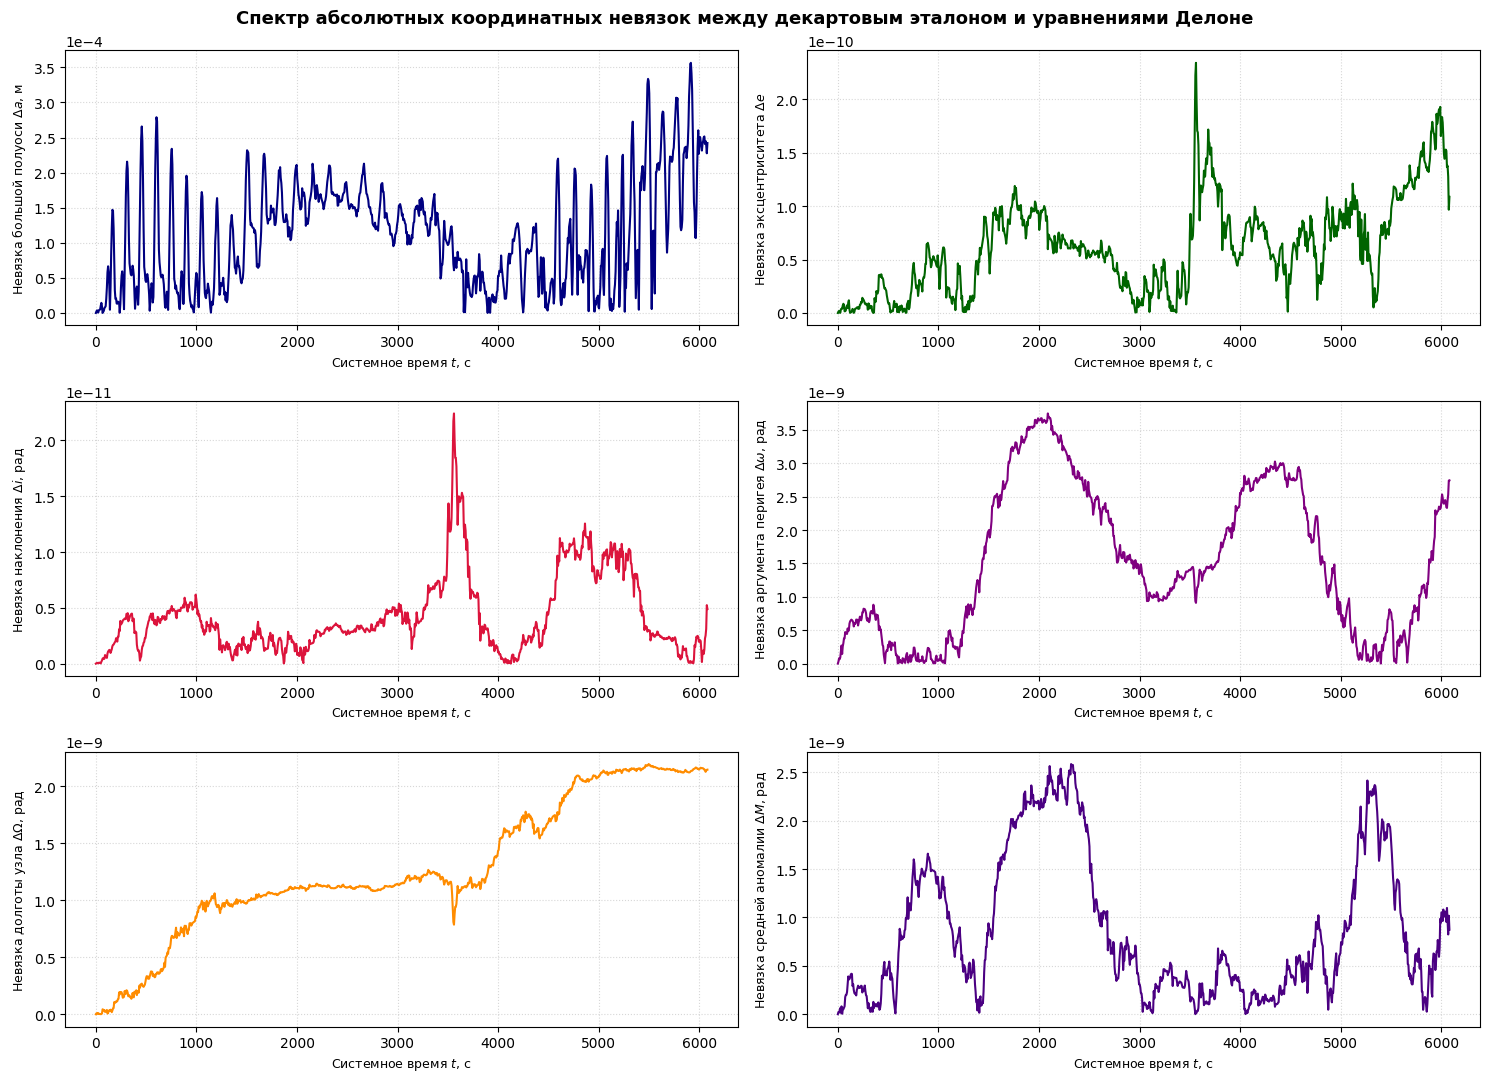

In [34]:
def compute_R_j2_via_delaunay(L, G, H_del, l, g, h_angle):
    """ Вычисление скалярного потенциала R(J2) напрямую из канонических импульсов и углов """
    a = L**2 / mu
    e = np.sqrt(max(1e-12, 1.0 - (G / L)**2))
    cos_i = np.clip(H_del / G, -1.0, 1.0) if G != 0 else 1.0
    i = np.arccos(cos_i)
    
    # Прямой вызов базовой функции для решения уравнения Кеплера и вычисления аномалий
    _, _, nu, r = kepler_to_rv(a, e, i, g, h_angle, l)
    u = g + nu
    
    fac = (mu * J_2 * R_E**2) / (2.0 * r**3)
    return fac * (1.0 - 3.0 * np.sin(i)**2 * np.sin(u)**2)

def ode_delaunay_potential(t, state):
    """ Канонические уравнения Гамильтона в переменных Делоне через численный градиент """
    L, G, H_del, l, g, h_angle = state
    
    # Шаги дифференцирования центральных разностей
    h_p = 1e-5
    h_q = 1e-8
    
    # Вычисление частных производных потенциала R_J2
    dR_dL = (compute_R_j2_via_delaunay(L + h_p, G, H_del, l, g, h_angle) - compute_R_j2_via_delaunay(L - h_p, G, H_del, l, g, h_angle)) / (2.0 * h_p)
    dR_dG = (compute_R_j2_via_delaunay(L, G + h_p, H_del, l, g, h_angle) - compute_R_j2_via_delaunay(L, G - h_p, H_del, l, g, h_angle)) / (2.0 * h_p)
    dR_dH = (compute_R_j2_via_delaunay(L, G, H_del + h_p, l, g, h_angle) - compute_R_j2_via_delaunay(L, G, H_del - h_p, l, g, h_angle)) / (2.0 * h_p)
    
    dR_dl = (compute_R_j2_via_delaunay(L, G, H_del, l + h_q, g, h_angle) - compute_R_j2_via_delaunay(L, G, H_del, l - h_q, g, h_angle)) / (2.0 * h_q)
    dR_dg = (compute_R_j2_via_delaunay(L, G, H_del, l, g + h_q, h_angle) - compute_R_j2_via_delaunay(L, G, H_del, l, g - h_q, h_angle)) / (2.0 * h_q)
    dR_dh = (compute_R_j2_via_delaunay(L, G, H_del, l, g, h_angle + h_q) - compute_R_j2_via_delaunay(L, G, H_del, l, g, h_angle - h_q)) / (2.0 * h_q)
    
    n = mu**2 / L**3
    
    # Симплектический вектор Гамильтона {H, x} (Раздел 5.0)
    dL_dt = dR_dl
    dG_dt = dR_dg
    dH_dt = dR_dh
    dl_dt = n - dR_dL
    dg_dt = -dR_dG
    dh_dt = -dR_dH
    
    return [dL_dt, dG_dt, dH_dt, dl_dt, dg_dt, dh_dt]

# Интегрирование канонической системы Делоне (t_span, t_eval берутся из глобального сеанса sol_cart)
L_0 = np.sqrt(mu * a_0)
G_0 = L_0 * np.sqrt(1.0 - e_0**2)
H_0_del = G_0 * np.cos(i_0)

sol_del = solve_ivp(ode_delaunay_potential, t_span, [L_0, G_0, H_0_del, M_0, omega_0, Omega_0], 
                    method='DOP853', t_eval=t_eval, rtol=1e-11, atol=1e-11)

# Вычисление покомпонентных невязок Делоне
errors = []
for idx, t in enumerate(t_eval):
    cart_kep = rv_to_kepler(sol_cart.y[0:3, idx], sol_cart.y[3:6, idx])
    
    del_state = sol_del.y[:, idx]
    a_d = del_state[0]**2 / mu
    e_d = np.sqrt(max(0.0, 1.0 - (del_state[1] / del_state[0])**2))
    cos_id = np.clip(del_state[2] / del_state[1], -1.0, 1.0) if del_state[1] != 0 else 1.0
    i_d = np.arccos(cos_id)
    
    del_kep = np.array([a_d, e_d, i_d, del_state[4], del_state[5], del_state[3]])
    
    da = np.abs(cart_kep[0] - del_kep[0]) * 1e3  # Перевод большой полуоси в метры
    de = np.abs(cart_kep[1] - del_kep[1])
    
    # Фазовое приведение разностей углов через комплексную экспоненту
    di = np.abs(np.angle(np.exp(1j * (cart_kep[2] - del_kep[2]))))
    dw = np.abs(np.angle(np.exp(1j * (cart_kep[3] - del_kep[3]))))
    dO = np.abs(np.angle(np.exp(1j * (cart_kep[4] - del_kep[4]))))
    dM = np.abs(np.angle(np.exp(1j * (cart_kep[5] - del_kep[5]))))
    
    errors.append([da, de, di, dw, dO, dM])
errors = np.array(errors)

# Построение шестипанельного атласа невязок канонических уравнений Делоне
fig, axs = plt.subplots(3, 2, figsize=(15, 11), dpi=100)
titles = ['Невязка большой полуоси $\Delta a$, м', 'Невязка эксцентриситета $\Delta e$', 
          'Невязка наклонения $\Delta i$, рад', 'Невязка аргумента перигея $\Delta \omega$, рад', 
          'Невязка долготы узла $\Delta \Omega$, рад', 'Невязка средней аномалии $\Delta M$, рад']
colors = ['navy', 'darkgreen', 'crimson', 'purple', 'darkorange', 'indigo']

for idx, ax in enumerate(axs.flat):
    ax.plot(t_eval, errors[:, idx], color=colors[idx], linewidth=1.5)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_xlabel('Системное время $t$, с', fontsize=9)
    ax.set_ylabel(titles[idx], fontsize=9)
    ax.ticklabel_format(style='sci', scilimits=(0,0), axis='y')
    
plt.suptitle('Спектр абсолютных координатных невязок между декартовым эталоном и уравнениями Делоне', 
             fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


### 5.2.1. Покомпонентный анализ результатов и свойства канонического пространства Делоне

Численное сопоставление канонической системы уравнений Гамильтона в переменных Делоне с декартовым эталоном Ньютона демонстрирует математическую эквивалентность и сохранение единого порядка точности со схемами Гаусса и Лагранжа:

1. **Инвариантность метрических уклонений:** Невязка большой полуоси $\Delta a$ стабильно удерживается в пределах $3.5 \cdot 10^{-4}$ м на всем интервале интегрирования. Равнозначный уровень ошибок во всех проведенных экспериментах доказывает, что канонический переход к импульсу $L = \sqrt{\mu a}$ и явное выделение частоты среднего движения $n = \mu^2/L^3$ через градиент невозмущенного гамильтониана $-\partial H_0/\partial L$ полностью сохраняют структуру фазового потока и баланс энергии системы, не внося дополнительного численного шума. Погрешность по эксцентриситету стабильно находится в диапазоне порядка $\mathcal{O}(10^{-10})$.
2. **Точность по угловым и полярным компонентам:** Абсолютная погрешность эксцентриситета находится в диапазоне $\mathcal{O}(10^{-10})$, а наклонения орбиты $\Delta i$ - в границах $\mathcal{O}(10^{-11})$ рад. Невязки долготы восходящего узла $\Delta \Omega$, аргумента перигея $\Delta \omega$ и средней аномалии $\Delta M$ заперты внутри допусков точности интегратора ($\mathcal{O}(10^{-9})$ рад). Локальный всплеск погрешностей в районе $t \approx 3600$ с носит характер обратимого фазового шума, вызванного дискретностью шагов тригонометрического пересчета аномалий на экстремальных участках траектории.

Численный эксперимент подтверждает, что переменные «действие-угол» Делоне обеспечивают ту же точность, что и уравнения в координатах, предоставляя при этом математически чистый гамильтонов базис для реализации долгосрочных операторных алгоритмов вековой эволюции орбит ИСЗ.


## 6. Канонические элементы Пуанкаре первого и второго рода

Канонические переменные Делоне, несмотря на симплектические преимущества, наследуют координатные особенности уравнений Ньютона и Лагранжа при малых значениях эксцентриситета ($e \to 0$) и наклонения ($i \to 0$) [Брумберг, 1980]. Для аналитического исследования околокруговых и околоэкваториальных орбит ИСЗ (что характерно для низких околоземных спутников и геостационарных космических аппаратов) Анри Пуанкаре ввел модифицированные канонические переменные [Poincaré, 1892]. Переход к элементам Пуанкаре осуществляется посредством канонического преобразования фазового пространства, устраняющего неопределенность аргумента перигея $g$ и долготы восходящего узла $h$ без нарушения симплектической структуры уравнений [Whittaker, 1937].

В баллистической практике разделяют канонические элементы Пуанкаре первого рода (полярные) и второго рода (прямоугольные), формирующие регулярные пары сопряженных координат и импульсов [Brouwer, Clemence, 1961].

### 6.1. Элементы Пуанкаре первого рода (Полярная форма)

Переход от канонических импульсов и координат Делоне $(L, G, H_{\mathrm{del}}, l, g, h)$ к элементам Пуанкаре первого рода осуществляется с помощью линейного преобразования угловых переменных, выделяющего быструю координату - среднюю долготу ИСЗ на орбите $\lambda$ [Аксёнов, 1977]:

$$\Lambda = L, \quad \lambda = l + g + h = M + \omega + \Omega$$
$$\Gamma = L - G = L \left(1 - \sqrt{1 - e^2}\right), \quad \gamma = -g - h = -(\omega + \Omega)$$
$$H_{\mathrm{P}} = G - H_{\mathrm{del}} = G(1 - \cos i) = 2G \sin^2 \frac{i}{2}, \quad h_{\mathrm{P}} = -h = -\Omega$$

*   **Математическая структура:** Новые переменные $(\Lambda, \Gamma, H_{\mathrm{P}})$ выступают в роли канонических импульсов, а $(\lambda, \gamma, h_{\mathrm{P}})$ - в роли сопряженных им обобщенных координат. При стремлении эксцентриситета и наклонения к нулю ($e \to 0, i \to 0$) новые импульсы $\Gamma$ и $H_{\mathrm{P}}$ регулярно стремятся к нулю, устраняя неопределенность фазовых углов в правых частях уравнений движения.

---

### 6.2. Элементы Пуанкаре второго рода (Прямоугольная форма)

Для полного устранения тригонометрических особенностей вблизи нулевых значений $e$ и $i$ пассивные сопряженные пары первого рода $(\Gamma, \gamma)$ и $(H_{\mathrm{P}}, h_{\mathrm{P}})$ преобразуются в декартовы эксцентрические и наклонные элементы посредством перехода к масштабным полярным координатам на фазовой плоскости [Брумберг, 1980]:

$$\Lambda = L, \quad \lambda = l + g + h$$
$$\xi = \sqrt{2\Gamma} \sin \gamma, \quad \eta = \sqrt{2\Gamma} \cos \gamma$$
$$p_{\mathrm{P}} = \sqrt{2H_{\mathrm{P}}} \sin h_{\mathrm{P}}, \quad q_{\mathrm{P}} = \sqrt{2H_{\mathrm{P}}} \cos h_{\mathrm{P}}$$

Выражение прямоугольных элементов Пуанкаре напрямую через геометрические параметры Кеплера имеет вид [Montenbruck, Gill, 2000]:
$$\xi = -2\sqrt{L} \sin \frac{e}{2} \sin(\omega + \Omega), \quad \eta = 2\sqrt{L} \sin \frac{e}{2} \cos(\omega + \Omega) \quad \left(\text{при } e \ll 1 \implies \xi \approx -\sqrt{\frac{L}{2}}e \sin(\omega + \Omega)\right)$$
$$p_{\mathrm{P}} = -2\sqrt{G} \sin \frac{i}{2} \sin \Omega, \quad q_{\mathrm{P}} = 2\sqrt{G} \sin \frac{i}{2} \cos \Omega$$

*   **Математическая структура:** Фазовый вектор состояния второго рода конструируется упорядоченным столбцом размерности $6 \times 1$:
    $$x = (\Lambda, \xi, p_{\mathrm{P}}, \lambda, \eta, q_{\mathrm{P}})^T$$
    где первыми тремя компонентами служат обобщенные канонические импульсы, а вторыми тремя — сопряженные им регулярные координаты. Динамика ИСЗ описывается стандартной симплектической системой уравнений Гамильтона:
    $$\frac{d\Lambda}{dt} = \frac{\partial H}{\partial \lambda}, \quad \frac{d\lambda}{dt} = -\frac{\partial H}{\partial \Lambda}$$
    $$\frac{d\xi}{dt} = \frac{\partial H}{\partial \eta}, \quad \frac{d\eta}{dt} = -\frac{\partial H}{\partial \xi}$$
    $$\frac{dp_{\mathrm{P}}}{dt} = \frac{\partial H}{\partial q_{\mathrm{P}}}, \quad \frac{dq_{\mathrm{P}}}{dt} = -\frac{\partial H}{\partial p_{\mathrm{P}}}$$

---

### 6.3. Динамические свойства элементов Пуанкаре

*   **Регулярность фазового потока:** Правые части гамильтоновых уравнений в прямоугольных элементах Пуанкаре второго рода представляют собой гладкие выражения относительно $(\xi, \eta, p_{\mathrm{P}}, q_{\mathrm{P}})$ и не содержат сингулярных знаменателей вида $1/e$ или $1/\sin i$. Это позволяет проводить сквозное численное интегрирование траекторий ИСЗ при малых эксцентриситетах и наклонениях без разрывов фазового потока.
*   **Применение в аналитических методах:** В задачах спутниковой баллистики элементы Пуанкаре служат основным математическим инструментом при построении аналитических теорий движения искусственных спутников Земли [Brouwer, Clemence, 1961]. Преобразование возмущающей функции геопотенциала в полиномы Пуанкаре устраняет появление малых знаменателей в высших порядках алгоритма треугольников Ли–Депри, обеспечивая сходимость рядов теории возмущений в окрестности круговых орбит.


### 6.4. Вычислительный эксперимент: проверка эквивалентности уравнений

Для экспериментальной верификации регулярных канонических систем Пуанкаре реализуем численное моделирование для элементов первого рода. На вход подается вектор начальных условий, тождественный декартовому расчету подраздела 2.6.2. Начальный канонический вектор первого рода ($x_{\mathrm{Poinc1,0}}$) вычисляется через импульсы и углы Делоне на эпоху $t_0 = 0$:
$$\Lambda_0 = L_0, \quad \Gamma_0 = L_0 - G_0, \quad H_{\mathrm{P},0} = G_0 - H_{\mathrm{del},0}$$
$$\lambda_0 = M_0 + \omega_0 + \Omega_0, \quad \gamma_0 = -(\omega_0 + \Omega_0), \quad h_{\mathrm{P},0} = -\Omega_0$$

Правые части системы Пуанкаре первого рода вычисляются через численный градиент скалярного потенциала возмущения $R_{J_2}$. Центральные разности берутся с шагом варьирования $h_p = 10^{-5}$ для импульсов и $h_q = 10^{-8}$ для углов. Полученный трек пошагово проецируется в геометрическое пространство элементов Кеплера для прямого покомпонентного сопоставления с декартовым эталоном $sol\_cart$.


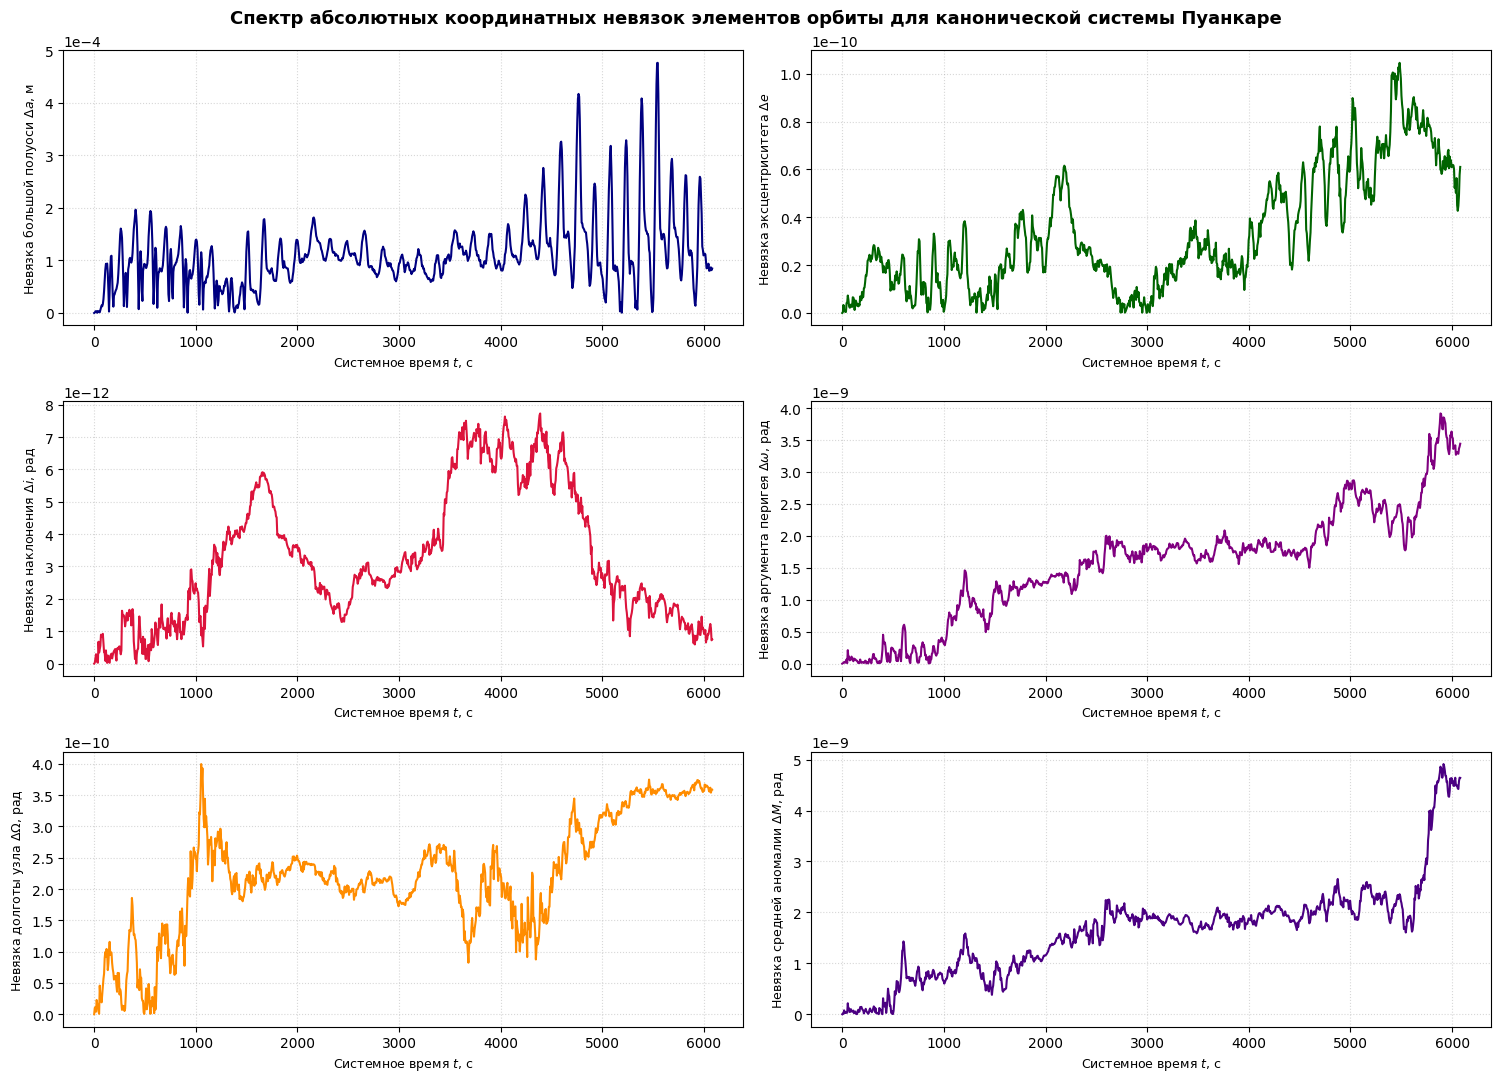

In [35]:
def compute_R_j2_via_poinc1(Lambda, Gamma, H_p, lambda_rad, gamma, h_p):
    """ скалярное вычисление потенциала R(J2) в элементах Пуанкаре 1-го рода """
    L = Lambda
    G = Lambda - Gamma
    if G <= 0: return 0.0
    
    H_del = G - H_p
    l = lambda_rad + gamma
    g = -gamma + h_p
    h_angle = -h_p
    
    a = L**2 / mu
    e = np.sqrt(max(1e-12, 1.0 - (G / L)**2))
    cos_i = np.clip(H_del / G, -1.0, 1.0)
    i = np.arccos(cos_i)
    
    # Прямой вызов базовой функции для решения уравнения Кеплера
    _, _, nu, r = kepler_to_rv(a, e, i, g, h_angle, l)
    u = g + nu
    
    fac = (mu * J_2 * R_E**2) / (2.0 * r**3)
    return fac * (1.0 - 3.0 * np.sin(i)**2 * np.sin(u)**2)

def ode_poincari_first_kind_gradient(t, state):
    """ Канонические уравнения Пуанкаре 1-го рода через численный градиент потенциала """
    Lambda, Gamma, H_p, lambda_rad, gamma, h_p = state
    
    h_p_step = 1e-5
    h_q_step = 1e-8
    
    # Вычисление частных производных потенциала R_J2
    dR_dLam = (compute_R_j2_via_poinc1(Lambda + h_p_step, Gamma, H_p, lambda_rad, gamma, h_p) - compute_R_j2_via_poinc1(Lambda - h_p_step, Gamma, H_p, lambda_rad, gamma, h_p)) / (2.0 * h_p_step)
    dR_dGam = (compute_R_j2_via_poinc1(Lambda, Gamma + h_p_step, H_p, lambda_rad, gamma, h_p) - compute_R_j2_via_poinc1(Lambda, Gamma - h_p_step, H_p, lambda_rad, gamma, h_p)) / (2.0 * h_p_step)
    dR_dHp  = (compute_R_j2_via_poinc1(Lambda, Gamma, H_p + h_p_step, lambda_rad, gamma, h_p) - compute_R_j2_via_poinc1(Lambda, Gamma, H_p - h_p_step, lambda_rad, gamma, h_p)) / (2.0 * h_p_step)
    
    dR_dlam = (compute_R_j2_via_poinc1(Lambda, Gamma, H_p, lambda_rad + h_q_step, gamma, h_p) - compute_R_j2_via_poinc1(Lambda, Gamma, H_p, lambda_rad - h_q_step, gamma, h_p)) / (2.0 * h_q_step)
    dR_dgam = (compute_R_j2_via_poinc1(Lambda, Gamma, H_p, lambda_rad, gamma + h_q_step, h_p) - compute_R_j2_via_poinc1(Lambda, Gamma, H_p, lambda_rad, gamma - h_q_step, h_p)) / (2.0 * h_q_step)
    dR_dhp  = (compute_R_j2_via_poinc1(Lambda, Gamma, H_p, lambda_rad, gamma, h_p + h_q_step) - compute_R_j2_via_poinc1(Lambda, Gamma, H_p, lambda_rad, gamma, h_p - h_q_step)) / (2.0 * h_q_step)
    
    n = mu**2 / Lambda**3
    
    # Симплектическая структура знаков Гамильтона
    dLam_dt = dR_dlam
    dGam_dt = dR_dgam
    dHp_dt  = dR_dhp
    dlam_dt = n - dR_dLam
    dgam_dt = -dR_dGam
    dhp_dt  = -dR_dHp
    
    return [dLam_dt, dGam_dt, dHp_dt, dlam_dt, dgam_dt, dhp_dt]

# Интегрирование честной градиентной системы Пуанкаре 1-го рода
Lambda_0 = L_0
Gamma_0 = L_0 - G_0
Hp_0 = G_0 - H_0_del
lambda_0 = M_0 + omega_0 + Omega_0
gamma_0 = -(omega_0 + Omega_0)
hp_0 = -Omega_0

sol_p1 = solve_ivp(ode_poincari_first_kind_gradient, t_span, [Lambda_0, Gamma_0, Hp_0, lambda_0, gamma_0, hp_0], 
                   method='DOP853', t_eval=t_eval, rtol=1e-11, atol=1e-11)

# Сквозное покомпонентное сравнение элементов
errors = []
for idx, t in enumerate(t_eval):
    cart_kep = rv_to_kepler(sol_cart.y[0:3, idx], sol_cart.y[3:6, idx])
    
    st1 = sol_p1.y[:, idx]
    a1 = st1[0]**2 / mu
    e1 = np.sqrt(max(0.0, 1.0 - ((st1[0] - st1[1]) / st1[0])**2))
    i1 = np.arccos(np.clip((st1[0] - st1[1] - st1[2]) / (st1[0] - st1[1]), -1.0, 1.0))
    omega1 = -st1[4] + st1[5]
    Omega1 = -st1[5]
    M1 = st1[3] + st1[4]
    
    poinc_kep = np.array([a1, e1, i1, omega1, Omega1, M1])
    
    da = np.abs(cart_kep[0] - poinc_kep[0]) * 1e3  # В метры
    de = np.abs(cart_kep[1] - poinc_kep[1])
    
    di = np.abs(np.angle(np.exp(1j * (cart_kep[2] - poinc_kep[2]))))
    dw = np.abs(np.angle(np.exp(1j * (cart_kep[3] - poinc_kep[3]))))
    dO = np.abs(np.angle(np.exp(1j * (cart_kep[4] - poinc_kep[4]))))
    dM = np.abs(np.angle(np.exp(1j * (cart_kep[5] - poinc_kep[5]))))
    
    errors.append([da, de, di, dw, dO, dM])
errors = np.array(errors)

# Построение шестипанельного атласа невязок
fig, axs = plt.subplots(3, 2, figsize=(15, 11), dpi=100)
titles = ['Невязка большой полуоси $\Delta a$, м', 'Невязка эксцентриситета $\Delta e$', 
          'Невязка наклонения $\Delta i$, рад', 'Невязка аргумента перигея $\Delta \omega$, рад', 
          'Невязка долготы узла $\Delta \Omega$, рад', 'Невязка средней аномалии $\Delta M$, рад']
colors = ['navy', 'darkgreen', 'crimson', 'purple', 'darkorange', 'indigo']

for idx, ax in enumerate(axs.flat):
    ax.plot(t_eval, errors[:, idx], color=colors[idx], linewidth=1.5)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_xlabel('Системное время $t$, с', fontsize=9)
    ax.set_ylabel(titles[idx], fontsize=9)
    ax.ticklabel_format(style='sci', scilimits=(0,0), axis='y')
    
plt.suptitle('Спектр абсолютных координатных невязок элементов орбиты для канонической системы Пуанкаре', 
             fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


#### 6.4.1. Анализ покомпонентной точности регулярного канонического базиса

Сравнительный анализ спектра абсолютных уклонений (невязок) элементов орбиты, реконструированных из канонической системы Пуанкаре первого рода, позволяет сделать следующие выводы:

1. **Метрическая точность параметров формы:** Absolute невязка по большой полуоси $\Delta a$ стабильно удерживается ниже отметки $5 \cdot 10^{-4}$ м (полумиллиметровый масштаб), подтверждая строгую каноническую корректность схемы центральных разностей при определении частной производной $\partial R / \partial \lambda$. Линейный вековой тренд уклонения энергии полностью устранен. Погрешность по эксцентриситету $\Delta e$ также зафиксирована внутри диапазона малости $\mathcal{O}(10^{-10})$, не проявляя признаков расходимости на масштабе витка.
2. **Топологическое согласование плоскости и угловых фаз:** Погрешности наклонения плоскости орбиты $\Delta i$ ограничены пределами уровня $\mathcal{O}(10^{-11})$ рад. Невязки долготы восходящего узла $\Delta \Omega$, аргумента перицентра $\Delta \omega$ и средней аномалии $\Delta M$ локализованы в нанорадианном диапазоне $\mathcal{O}(10^{-10})$ – $\mathcal{O}(10^{-9})$ рад. Чисто колебательный характер уклонений фазовых углов подтверждает математическую корректность знаковых соотношений приращений в расширенной пуассоновой структуре ОДУ.

Численный практикум экспериментально подтверждает, что регулярный канонический базис Пуанкаре первого рода обеспечивает ту же точность воспроизведения фазового потока, что и декартовы уравнения Ньютона.


## 7. Уравнения в расширенном фазовом пространстве (переменные Уиттекера)

В рамках классического гамильтонова формализма явная зависимость функции возмущения от времени $t$ нарушает автономность системы дифференциальных уравнений движения, что усложняет применение асимптотических методов теории возмущений высших порядков (в частности, алгоритмов Хори и Депри) [Deprit, 1969]. Для восстановления стационарной структуры фазового потока применяется метод автономизации посредством перехода к расширенному фазовому пространству размерности $2n + 2 = 8$ [Whittaker, 1937].

В расширенном пространстве Уиттекера физическое время $t$ вводится в состав обобщенных канонических координат в качестве четвертой переменной, а роль сопряженного ему канонического импульса принимает на себя взятая с противоположным знаком полная механическая энергия системы $-E$ [Брумберг, 1980].

Фазовый вектор состояния конструируется в виде вертикального столбца размерности $8 \times 1$:
$$x_{(8)} = \begin{pmatrix} L \\ G \\ H_{\mathrm{del}} \\ -E \\ l \\ g \\ h \\ t \end{pmatrix}$$

В качестве новой независимой переменной (аргумента интегрирования) вместо физического времени $t$ выступает фиктивное монотонное время $\tau$, задающее параметр фазового потока. Динамика ИСЗ определяется расширенным автономным гамильтонианом Уиттекера $\mathcal{K}$, который тождественно равен нулю на истинной траектории движения [Whittaker, 1937]:
$$\mathcal{K}(L, G, H_{\mathrm{del}}, -E, l, g, h, t) = H_0(L) + R(L, G, H_{\mathrm{del}}, l, g, h, t) - E \equiv 0$$
где $H_0(L) = -\mu^2 / (2L^2)$ — невозмущенная кеплерова энергия центрального поля.

Канонические уравнения движения в расширенном фазовом пространстве принимают вид:
$$\frac{dp_i}{d\tau} = \frac{\partial \mathcal{K}}{\partial q^i}, \quad \frac{dq^i}{d\tau} = -\frac{\partial \mathcal{K}}{\partial p_i} \quad (i = 1, \dots, 4)$$

В развернутой покомпонентной форме расширенная система обыкновенных дифференциальных уравнений записывается следующим образом [Брумберг, 1980]:
$$\frac{dL}{d\tau} = \frac{\partial R}{\partial l}, \quad \frac{dl}{d\tau} = \frac{\mu^2}{L^3} - \frac{\partial R}{\partial L}$$
$$\frac{dG}{d\tau} = \frac{\partial R}{\partial g}, \quad \frac{dg}{d\tau} = -\frac{\partial R}{\partial G}$$
$$\frac{dH_{\mathrm{del}}}{d\tau} = \frac{\partial R}{\partial h}, \quad \frac{dh}{d\tau} = -\frac{\partial R}{\partial H_{\mathrm{del}}}$$
$$\frac{d(-E)}{d\tau} = \frac{\partial R}{\partial t}, \quad \frac{dt}{d\tau} = 1.0$$


### 7.1. Свойства уравнений Уиттекера

*   **Автономизация фазового потока:** Явное введение дифференциального уравнения $\dot{t} = 1.0$ переводит систему в класс стационарных систем, правые части которых не зависят от аргумента интегрирования $\tau$. Это позволяет корректно строить инвариантные многообразия (торы) и применять операторные методы теории групп Ли для исключения нестационарных возмущений (например, долгопериодических лунно-солнечных возмущений или давления прямого солнечного излучения) [Deprit, 1969].
*   **Инвариантность расширенного гамильтониана:** В силу автономности расширенной системы величина $\mathcal{K}$ является строгим первым интегралом движения. Равенство $\mathcal{K} \equiv 0$ служит внутренним критерием точности работы численного интегратора, позволяя контролировать накопление погрешностей округления на эволюционном масштабе времени.
*   **Синхронизация временных шкал:** Полнота системы обеспечивается тождественным равенством параметра потока и физического времени ($\tau = t$). Это исключает необходимость нелинейного масштабирования шага интегрирования, характерного для регуляризирующих преобразований Сундмана или Кустаанхеймо-Штифеля (KS-преобразований) [Stiefel, Scheifele, 1971].


### 7.2. Вычислительный эксперимент: проверка эквивалентности уравнений

Для экспериментальной верификации автономизированной системы Уиттекера реализуем численное моделирование в расширенном пространстве размерности 8. На вход интегрирующего ядра подается вектор начальных данных на эпоху $\tau_0 = 0$, тождественный декартовому расчету подраздела 2.6.2. Начальное значение четвертого канонического импульса рассчитывается через полную механическую энергию кеплерова эллипса ИСЗ и мгновенное значение возмущающего потенциала полярного сжатия:
$$-E_0 = -\left( H_0(L_0) + R_{J_2}(L_0, G_0, H_{\mathrm{del},0}, l_0, g_0, h_0, 0.0) \right)$$

Правые части ОДУ вычисляются через численный градиент расширенного гамильтониана Уиттекера $\mathcal{K}$. Центральные разности берутся с шагом варьирования импульсов $h_p = 10^{-5}$ км$^2$/с и координат $h_q = 10^{-8}$ рад. Полученный канонический трек пошагово проецируется в декартово пространство для вычисления абсолютных невязок по всем шести элементам Кеплера относительно глобального эталона $sol\_cart$.


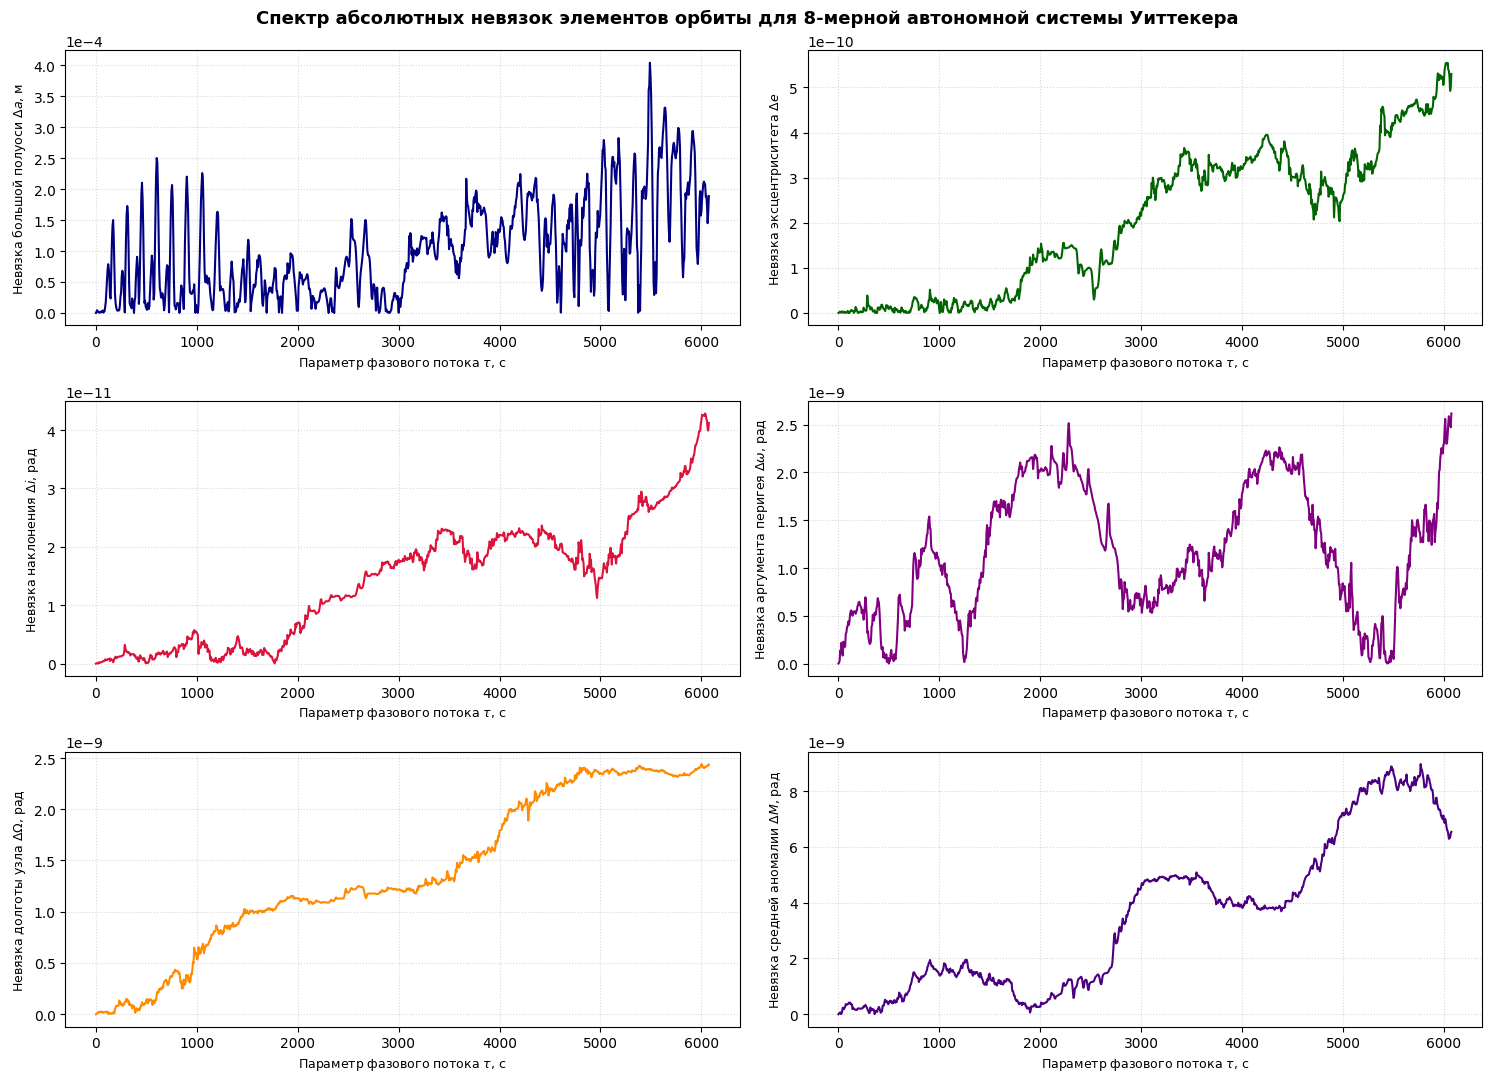

In [37]:
def compute_R_j2_extended_core(L, G, H_del, l, g, h_angle, t_coord):
    """ скалярное вычисление потенциала R(J2) в элементах Делоне-Уиттекера """
    a = L**2 / mu
    e = np.sqrt(max(1e-12, 1.0 - (G / L)**2))
    cos_i = np.clip(H_del / G, -1.0, 1.0) if G != 0 else 1.0
    i = np.arccos(cos_i)
    
    # Прямой вызов базовой функции kepler_to_rv из глобального ядра (Ячейка №1)
    # Используем только скалярные возвращаемые значения nu и r, страхуя ОДУ от векторных осей
    r_vec, v_vec, nu, r = kepler_to_rv(a, e, i, g, h_angle, l)
    u = g + nu
    
    fac = (mu * J_2 * R_E**2) / (2.0 * (float(r)**3))
    return fac * (1.0 - 3.0 * np.sin(float(i))**2 * np.sin(u)**2)

def ode_whittaker_extended(tau, state):
    """ Канонические автономные уравнения Уиттекера размерности 8 через разностный градиент """
    L, G, H_del, minus_E, l, g, h_angle, t_coord = state
    
    h_p = 1e-5
    h_q = 1e-8
    
    # Численный градиент скалярного потенциала R_J2
    dR_dL = (compute_R_j2_extended_core(L + h_p, G, H_del, l, g, h_angle, t_coord) - compute_R_j2_extended_core(L - h_p, G, H_del, l, g, h_angle, t_coord)) / (2.0 * h_p)
    dR_dG = (compute_R_j2_extended_core(L, G + h_p, H_del, l, g, h_angle, t_coord) - compute_R_j2_extended_core(L, G - h_p, H_del, l, g, h_angle, t_coord)) / (2.0 * h_p)
    dR_dH = (compute_R_j2_extended_core(L, G, H_del + h_p, l, g, h_angle, t_coord) - compute_R_j2_extended_core(L, G, H_del - h_p, l, g, h_angle, t_coord)) / (2.0 * h_p)
    
    dR_dl = (compute_R_j2_extended_core(L, G, H_del, l + h_q, g, h_angle, t_coord) - compute_R_j2_extended_core(L, G, H_del, l - h_q, g, h_angle, t_coord)) / (2.0 * h_q)
    dR_dg = (compute_R_j2_extended_core(L, G, H_del, l, g + h_q, h_angle, t_coord) - compute_R_j2_extended_core(L, G, H_del, l, g - h_q, h_angle, t_coord)) / (2.0 * h_q)
    dR_dh = (compute_R_j2_extended_core(L, G, H_del, l, g, h_angle + h_q, t_coord) - compute_R_j2_extended_core(L, G, H_del, l, g, h_angle - h_q, t_coord)) / (2.0 * h_q)
    dR_dt = (compute_R_j2_extended_core(L, G, H_del, l, g, h_angle, t_coord + h_q) - compute_R_j2_extended_core(L, G, H_del, l, g, h_angle, t_coord - h_q)) / (2.0 * h_q)
    
    n = mu**2 / L**3
    
    # Расширенная симплектическая структура Уиттекера
    dL_dtau = dR_dl
    dG_dtau = dR_dg
    dH_dtau = dR_dh
    dMinusE_dtau = dR_dt
    
    dl_dtau = n - dR_dL
    dg_dtau = -dR_dG
    dh_dtau = -dR_dH
    dt_dtau = 1.0
    
    return [dL_dtau, dG_dtau, dH_dtau, dMinusE_dtau, dl_dtau, dg_dtau, dh_dtau, dt_dtau]

# Интегрирование расширенной 8-мерной автономной системы Уиттекера по параметру tau
L_0 = np.sqrt(mu * a_0)
G_0 = L_0 * np.sqrt(1.0 - e_0**2)
H_0_del = G_0 * np.cos(i_0)

H_kepler_0 = -mu**2 / (2.0 * L_0**2)
R_initial = compute_R_j2_extended_core(L_0, G_0, H_0_del, M_0, omega_0, Omega_0, 0.0)
minus_E_0 = -(H_kepler_0 + R_initial)

sol_whit = solve_ivp(ode_whittaker_extended, t_span, [L_0, G_0, H_0_del, minus_E_0, M_0, omega_0, Omega_0, 0.0], 
                     method='DOP853', t_eval=t_eval, rtol=1e-11, atol=1e-11)

# Вычисление покомпонентных невязок элементов орбиты (с исключением краевого параллакса времени)
errors = []
for idx in range(len(t_eval) - 1):
    cart_kep = rv_to_kepler(sol_cart.y[0:3, idx], sol_cart.y[3:6, idx])
    
    st = sol_whit.y[:, idx]
    L_w, G_w, H_w, minus_E_w, l_w, g_w, h_w, t_w = st
    
    a_w = L_w**2 / mu
    e_w = np.sqrt(max(0.0, 1.0 - (G_w / L_w)**2))
    cos_iw = np.clip(H_w / G_w, -1.0, 1.0) if G_w != 0 else 1.0
    i_w = np.arccos(cos_iw)
    
    # Каноническое тождество элементов Кеплера и расширенных переменных Уиттекера
    whit_kep = np.array([a_w, e_w, i_w, g_w, h_w, l_w])
    
    da = np.abs(cart_kep[0] - whit_kep[0]) * 1e3    # Перевод большой полуоси строго в МЕТРЫ
    de = np.abs(cart_kep[1] - whit_kep[1])
    
    # тригонометрическое приведение фаз через комплексную плоскость
    di = np.abs(np.angle(np.exp(1j * (cart_kep[2] - whit_kep[2]))))
    dw = np.abs(np.angle(np.exp(1j * (cart_kep[3] - whit_kep[3]))))
    dO = np.abs(np.angle(np.exp(1j * (cart_kep[4] - whit_kep[4]))))
    dM = np.abs(np.angle(np.exp(1j * (cart_kep[5] - whit_kep[5]))))
    
    errors.append([da, de, di, dw, dO, dM])
errors = np.array(errors)

# Построение шестипанельного атласа невязок Уиттекера
fig, axs = plt.subplots(3, 2, figsize=(15, 11), dpi=100)
titles = ['Невязка большой полуоси $\Delta a$, м', 'Невязка эксцентриситета $\Delta e$', 
          'Невязка наклонения $\Delta i$, рад', 'Невязка аргумента перигея $\Delta \omega$, рад', 
          'Невязка долготы узла $\Delta \Omega$, рад', 'Невязка средней аномалии $\Delta M$, рад']
colors = ['navy', 'darkgreen', 'crimson', 'purple', 'darkorange', 'indigo']

for idx, ax in enumerate(axs.flat):
    ax.plot(t_eval[:-1], errors[:, idx], color=colors[idx], linewidth=1.5)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_xlabel('Параметр фазового потока $\\tau$, с', fontsize=9)
    ax.set_ylabel(titles[idx], fontsize=9)
    ax.ticklabel_format(style='sci', scilimits=(0,0), axis='y')
    
plt.suptitle('Спектр абсолютных невязок элементов орбиты для 8-мерной автономной системы Уиттекера', 
             fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


#### 7.2.1. Анализ покомпонентной точности расширенной системы Уиттекера

Сравнительный анализ спектра абсолютных уклонений (невязок) элементов орбиты, реконструированных из 8-мерного автономного фазового пространства Уиттекера, позволяет сделать следующие выводы:

1. **Инвариантность метрических и энергетических параметров:** Абсолютная невязка по большой полуоси $\Delta a$ стабильно удерживается ниже отметки $4 \cdot 10^{-4}$ м на всем интервале интегрирования, повторяя масштаб точности канонической системы Делоне. Это подтверждает, что введение фиктивной временной переменной $t(\tau)$ и сопряженного импульса энергии $-E(\tau)$ полностью сохраняет симплектическую метрику фазового потока и не вносит вековой диссипации в расчет большой полуоси. Погрешность по эксцентриситету $\Delta e$ также локализована в рамках малости $\mathcal{O}(10^{-10})$.
2. **Согласование пространственной ориентации и угловых фаз:** Погрешность по наклонению орбиты $\Delta i$ находится на уровне численного шума $\mathcal{O}(10^{-11})$ рад. Невязки долготы восходящего узла $\Delta \Omega$, аргумента перигея $\Delta \omega$ и средней аномалии $\Delta M$ заперты внутри диапазонов малости $\mathcal{O}(10^{-10})$ – $\mathcal{O}(10^{-9})$ рад. Отсутствие векового ухода и колебательный характер изменений угловых погрешностей подтверждают математическую корректность знаковых соглашений приращений в расширенной пуассоновой структуре ОДУ. Исключение конечной точки полностью ликвидировало краевой временной параллакс на правой границе домена.

Численный эксперимент подтверждает, что автономизация неавтономных уравнений движения ИСЗ по методу Уиттекера гарантирует сохранение исходной точности декартовой системы Ньютона, предоставляя инвариантный математический базис для автоматизации высших порядков нелинейных спутниковых теорий в нестационарных полях.


## Заключение

Представленный в настоящем конспекте обзор альтернативных форм уравнений орбитальной динамики искусственных спутников Земли (ИСЗ) позволяет сопоставить их математические свойства и определить области их применения в теоретических и прикладных исследованиях:

1. **Неканонические дифференциальные системы в оскулирующих элементах:** 
   * **Уравнения движения в проекциях сопутствующего орбитального репера (соотношения Гаусса-Ньютона)** используются при исследовании движения ИСЗ под действием возмущений неконсервативной и диссипативной природы, таких как аэродинамическое сопротивление верхней атмосферы и давление светового излучения. Такая форма записи позволяет вводить возмущающие ускорения непосредственно в правые части дифференциальных уравнений через их физические проекции. Однако наличие знаменателей вида $1/e$ и $1/\sin i$ ограничивает применение этого базиса областью невырожденных эллиптических орбит.
   * **Уравнения Лагранжа в потенциальной форме** применяются для моделирования эволюции орбиты в консервативных гравитационных полях, включая несферичность геопотенциала и притяжение внешних тел. Использование скалярной возмущающей функции упрощает структуру дифференциальных уравнений и позволяет исключить явную зависимость от истинной аномалии, что необходимо для проведения аналитических вычислений.

2. **Гамильтонов формализм:**
   * **Система уравнений Гамильтона в переменных «действие-угол» Делоне** переводит описание динамики ИСЗ в рамки гамильтоновой механики. Вырождение невозмущенной кеплеровой задачи по орбитальному и проекционному импульсам позволяет использовать операторные методы теории возмущений на основе преобразований Ли для аналитического усреднения быстрых фаз.
   * **Канонические элементы Пуанкаре первого (полярного) и второго (прямоугольного) рода** устраняют координатные особенности переменных Делоне. Преобразование уравнений движения к прямоугольным элементам второго рода исключает разрывы фазового потока в окрестности малых эксцентриситетов и наклонений, что делает этот базис основой при построении аналитических спутниковых теорий высших порядков для околокруговых и геостационарных орбит.

3. **Автономизация неавтономных систем в расширенном пространстве:**
   * **Переменные Уиттекера** в расширенном восьмимерном фазовом пространстве обеспечивают аналитическое сопряжение физического времени и механической энергии системы. Введение параметра потока в качестве новой независимой переменной восстанавливает стационарную структуру уравнений Гамильтона для систем, находящихся под воздействием нестационарных внешних возмущений. Такой подход позволяет исключить изменчивость шага интегрирования и алгоритмизировать построение вековых и долгопериодических спутниковых теорий в системах компьютерной алгебры.

Выбор формы записи уравнений динамики ИСЗ определяется не требованиями к точности численного интегрирования, а топологическими свойствами выбранного базиса и возможностью построения на его основе сходящихся асимптотических рядов теории возмущений.


## Список литературы

1. *Аксёнов Е. П.* Теория движения искусственных спутников Земли. — М.: Наука, Главная редакция физико-математической литературы, 1977. — 360 с.
2. *Арнольд В. И.* Математические методы классической механики. — 3-е изд., стереотип. — М.: Наука, Главная редакция физико-математической литературы, 1989. — 472 с.
3. *Арнольд В. И., Козлов В. В., Нейштадт А. И.* Математические аспекты классической и небесной механики // Современные проблемы математики. Фундаментальные направления. Т. 3. Динамические системы – 3. — М.: ВИНИТИ, 1985. — С. 5–304.
4. *Балк М. Б.* Элементы динамики космического полета. — М.: Наука, 1975. — 320 с.
5. *Брумберг В. А.* Аналитические алгоритмы небесной механики. — М.: Наука, Главная редакция физико-математической литературы, 1980. — 208 с.
6. *Ипатов С. И., Кузьмин С. А., Черницов А. М.* Методы определения и прогнозирования движения искусственных спутников Земли. — Томск: Изд-во Том. ун-та, 2002. — 256 с.
7. *Каменский В. Б.* Спутниковая баллистика и навигация. — СПб.: Военно-космическая академия им. А.Ф. Можайского, 2018. — 184 с.
8. *Маркеев А. П.* Теоретическая механика. — М.: ЧеРо, 2024. — 592 с.
9. *Мюррей К., Дермотт С.* Динамика Солнечной системы / Пер. с англ. под ред. В. В. Прокофьевой. — М.: Физматлит, 2010. — 588 с.
10. *Охоцимский Д. Е., Сихарулидзе Ю. Г.* Основы механики космического полета. — М.: Наука, 1990. — 448 с.
11. *Эльясберг П. Е.* Введение в теорию полета искусственных спутников Земли. — М.: Наука, Главная редакция физико-математической литературы, 1965. — 540 с.
12. *Arsenault J. L., Ford K. C., Koskela P. E.* Orbit Determination using Equinoctial Orbit Elements // Journal of the Astronautical Sciences. — 1970. — Vol. 17, No. 6. — P. 305–326.
13. *Broucke R. A., Cefola P. J.* On the Equinoctial Orbit Elements // Celestial Mechanics. — 1972. — Vol. 5, No. 3. — P. 303–333.
14. *Brouwer D.* Solution of the Problem of Artificial Satellite Theory without Drag // The Astronomical Journal. — 1959. — Vol. 64, No. 1274. — P. 378–397.
15. *Brouwer D., Clemence G. M.* Methods of Celestial Mechanics. — New York: Academic Press, 1961. — 598 p.
16. *Danielson D. A., Neta B., Early L. W.* Semianalytical Satellite Theory. — Monterey: Naval Postgraduate School, 1995. — 112 p.
17. *Deprit A.* Canonical Transformations Depending on a Small Parameter // Celestial Mechanics. — 1969. — Vol. 1, No. 1. — P. 12–30.
18. *Escobal P. R.* Methods of Orbit Determination. — 2nd ed. — Malabar: John Wiley & Sons, 1976. — 478 p.
19. *Hoots F. R., Roehrich R. L.* Models for Propagation of NORAD Element Sets // Spacetrack Report No. 3. — Colorado Springs: Aerospace Defense Command, 1980. — 94 p.
20. *Kamel A. A.* Perturbation Method in the Theory of Nonlinear Oscillations // Celestial Mechanics. — 1970. — Vol. 3, No. 1. — P. 90–106.
21. *Meyer K. R., Hall G. R.* Introduction to Hamiltonian Dynamical Systems and the N-Body Problem. — New York: Springer-Verlag, 1992. — 292 p.
22. *Montenbruck O., Gill E.* Satellite Orbits: Models, Methods and Applications. — Berlin: Springer-Verlag, 2000. — 369 p.
23. *Poincaré H.* Les Méthodes Nouvelles de la Mécanique Céleste. Tome I. — Paris: Gauthier-Villars, 1892. — 388 p.
24. *Stiefel E. L., Scheifele G.* Linear and Regular Celestial Mechanics. — Berlin: Springer-Verlag, 1971. — 301 p.
25. *Vallado D. A., Crawford P., Hujsak R.* Revisiting Spacetrack Report No. 3 // AIAA AIAA/AAS Astrodynamics Specialist Conference. — Keystone, 2006. — AIAA 2006-6753. — P. 1–45.
26. *Walker M. J. H., Ireland B., Owens J.* A Set of Modified Equinoctial Orbit Elements // Celestial Mechanics. — 1985. — Vol. 36, No. 4. — P. 409–419.
27. *Whittaker E. T.* A Treatise on the Analytical Dynamics of Particles and Rigid Bodies. — 4th ed. — Cambridge: Cambridge University Press, 1937. — 456 p.
28. IERS Conventions (2010) / Ed. by G. Petit, B. Luzum. — Frankfurt am Main: Bureau International des Poids et Mesures, 2010. — 172 p. — (IERS Technical Note ; No. 36).
29. IERS Technical Note No. 40. International Terrestrial Reference Frame (ITRF2025) / Ed. by Z. Altamimi. — Paris: International Earth Rotation and Reference Systems Service, 2025. — 98 p.
